# Portal Optimization Engagement Index — v2

**Reporting period:** `2026-08-01` → `2026-08-31`  
**Profile:** `ShazebAsad`  
**Active population:** Active on any day in month: `is_relevant = true` (base scoped by is_relevant, Aug 2026)

**Structure:** F1–F6 each have their own section (navigation map → event discovery → classification table → standalone reach). F6 Bookings and F8 Messaging were excludedns are kept for reference but **excluded from the metric**. Combined scoring (Outputs A–M) uses 6 features: F1, F2, F3, F4, F5, F6.


In [1]:
# ── Databricks connection setup ──────────────────────────────────────────
# Uses analytics-warehouse (RUNNING) via databricks-sql-connector.
# The connector keeps a persistent session so TEMP VIEWs survive across cells.
# No cluster or databricks-connect version required.
import subprocess, json, pandas as pd
from databricks import sql as _dbsql
from IPython.display import display as _display

# Refresh OAuth token from the CLI cache — valid for 1 h, run this cell again if it expires
_tok = json.loads(subprocess.check_output(
    ['databricks', 'auth', 'token', '--profile', 'ShazebAsad'], text=True
))

_conn = _dbsql.connect(
    server_hostname='dbc-d10db17d-b6c4.cloud.databricks.com',
    http_path='/sql/1.0/warehouses/774b0b6877dcd0c3',  # analytics-warehouse
    access_token=_tok['access_token'],
    catalog='production',
)
_cursor = _conn.cursor()

class _Spark:
    def sql(self, statement):
        _cursor.execute(statement)
        if _cursor.description:
            cols = [d[0] for d in _cursor.description]
            return pd.DataFrame(_cursor.fetchall(), columns=cols)
        return pd.DataFrame()

spark   = _Spark()
display = _display
print('Connected → analytics-warehouse (774b0b6877dcd0c3)')

# Month axis labels: '2026-08' -> 'Aug-26'
def fmt_month(m):
    import datetime as _dt
    m = str(m)[:7]
    try:
        return _dt.datetime.strptime(m, '%Y-%m').strftime('%b-%y')
    except ValueError:
        return m
def fmt_months(seq):
    return [fmt_month(x) for x in seq]

# Shade the window where all 6 features report at full volume (Apr 2026 onward)
def mark_full_instr(ax, months_raw, text='All 6 features live'):
    ms = [str(m)[:7] for m in months_raw]
    if '2026-04' not in ms:
        return
    i = ms.index('2026-04')
    ax.axvspan(i - 0.5, len(ms) - 0.5, color='#2e72b8', alpha=0.07, zorder=0)
    ax.axvline(i - 0.5, color='#2e72b8', linestyle='--', linewidth=1.2, zorder=1)
    ax.text(i - 0.35, 0.97, text, transform=ax.get_xaxis_transform(),
            fontsize=8, color='#2e72b8', fontweight='bold', va='top')


/Users/shazeb.asad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Connected → analytics-warehouse (774b0b6877dcd0c3)


## Setup — Source tables

| Table | Role |
|---|---|
| `production.core_supply.agg_supplier_lifecycle_daily` | Lifecycle stage, acquisition date, `bookable_activity_count`, `bookings_l365` per supplier per snapshot date |
| `production.core_supply.agg_supplier_portal_events_session_daily` | Portal clickstream, pre-filtered (staff / GYG / office IPs excluded, dbt PR #2788) |

**Lifecycle stages:** `01. Created` · `02. Pre-Activated` · `03. Activated` · `04. Dormant` · `05. Churned`

---
# Metric Methodology & Versioning

This section is the authoritative reference for how the Supplier Portal Engagement metric is defined, versioned, and maintained over time. It should be updated whenever the metric definition changes.


---
## What the metric measures

**Portal Optimization Engagement Index** measures how many of the six reference portal features each active supplier actually used in a given month, averaged across all active suppliers and expressed against a fixed base of 6 features set to 100.

```
Supplier index = (features reached by supplier) / 6 x 100

Headline index = AVG(supplier index) across all active suppliers

Index 100 = the average active supplier uses six optimization features.
The base of 6 is fixed and does not move when features are added to the numerator,
so the index can rise above 100 once the metric covers more than six features.
```

**Why per-supplier averaging instead of aggregate counts?**  
Aggregate counts are dominated by large, highly-active suppliers. Per-supplier averaging gives equal weight to every supplier — a single-product supplier who uses 4 out of 5 relevant features contributes the same as a 50-product supplier who does the same. This makes the index a true measure of *breadth* of engagement, not *volume*.

**Why per-feature eligibility instead of a single denominator?**  
Some features only make sense for suppliers with existing bookings (Performance, Reviews). Counting those features against suppliers with zero bookings would permanently depress their score for reasons outside their control. Each feature has its own eligibility gate. Every supplier in scope satisfies both entry conditions by construction, so all 6 features are relevant for every in-scope supplier and the base is 6 for everyone.

**Note on column names:** headline-metric columns keep the `_pct` suffix from v1 (`avg_engagement_pct`, `engagement_score_pct`). Those values are index points on the fixed base of 6 and are numerically identical to the v1 percentages. Columns named `*_reach_pct` remain true percentages of suppliers.


---
## v1 Feature definitions

6 features in the metric. F6 Bookings Management and F8 Customer Messaging are documented in the version history but excluded from scoring.

| # | Feature | Eligibility gate | Signal | Containers | Metric |
|---|---|---|---|---|---|
| F1 | Product Content Editing | `bookable_activity_count > 0` | Supplier saves a content step in the existing product editor, manages keywords or addresses, or saves the option management panel | `ProductDetails` | **included** |
| F2 | Pricing Configuration | `bookable_activity_count > 0` | Supplier saves option pricing/availability configuration, or creates/updates an additional pricing rule | `ProductDetails`, `availability-and-pricing` | **included** |
| F3 | Performance Views | `bookings_l365 > 0` | Fired at least one interaction event (filter, date range, product drilldown) | `SupplierPerformance`, `SupplierProductPerformance` | **included** |
| F4 | Availability Management | `bookable_activity_count > 0` | Any confirmed save on availability (block/unblock, capacity, cut-off, schedule), or saves the option management panel | `SupplierAgenda`, `SupplierCalendar`, `availability-and-pricing`, `ProductDetails` | **included** |
| F5 | Special Offers | `bookable_activity_count > 0` | Entered the deal creation flow or deleted an existing offer (one-click deal CTA excluded) | `SupplierSpecialOffers` | **included** |
| F6 | Review Responses | `bookings_l365 > 0` | Submitted at least one review reply | `SupplierReviews` | **included** |

**Supplier base:** Suppliers where `MAX(bookable_activity_count) > 0` AND `MAX(bookings_l365) > 0` on any day within the reporting month. No lifecycle stage filter.  
**Events source:** `production.core_supply.agg_supplier_portal_events_session_daily` (pre-filtered — GYG staff, internal IPs, and GYG-owned supplier accounts excluded).

---

---
## Instrumentation changelog — v1

The table below records when each feature's primary signal events first appeared in the portal clickstream. Months before the **Clean from** date are labelled *(partial)* and must not be used for trend comparisons.

| Feature | Key signal event(s) | First fired | Clean from | Notes |
|---|---|---|---|---|
| F1 | `ProductDetails.SaveStepButton` | 2026-01-01 | 2026-01 | Present from start |
| F1 (excluded) | `SupplierCreateProduct.SaveStepButton` | 2026-01-01 | 2026-01 | Present from start; excluded from F1 (new product creation, not editing) |
| F1 | `ProductDetails.OptionManagementPanelSaveButton` | ~2026-01-26 | **2026-02** | Panel save button — counts directly (no session proxy). Jan data near-zero. |
| F2 | `CreatedAdditionalPricing`, `UpdatedAdditionalPricing` | 2026-01-01 | 2026-01 | Present from start |
| F3 | `SupplierPerformance.*` | **2026-02-17** | **2026-03** | Container launched Feb 17. Feb ramp-up period; March is first full month |
| F4 | `SupplierAgenda.BlockDateButton` | 2026-01-01 | 2026-01 | Core event, present from start |
| F4 | `availability-and-pricing.AvailabilityAndPricingAddSchedule` | ~2026-02-10 | **2026-03** | Standalone availability surface launched mid-Feb |
| F4 | `ProductDetails.AvailabilityAndPricingSaveAndContinueButton` | ~2026-02-01 | **2026-03** | In-editor availability save launched early Feb |
| F5 | `SupplierOneClickDealCTAClick` | 2026-01-01 | 2026-01 | **F5 (excluded)** — post-submission activation CTA removed from F5 definition; Statsig rollout caused June-July spike |
| F5 | `CreateDealOffersHub` | 2026-01-01 | 2026-01 | Present from start |
| F6 (excluded) | `SupplierBookings.SupplierBookingAction` | 2026-01-01 | 2026-01 | Core event, present from start |
| F6 (excluded) | `SupplierBookingsManage.SupplierBookingsManagePageAction` | 2026-01-01 | 2026-01 | Present from start |
| F6 | `SupplierReviews.ReviewCardReplySubmit` | 2026-01-01 | 2026-01 | Clean from start; organic upward trend |
| F8 (excluded) | `SupplierBookingDetails.SupplierMessagesAction` | 2026-01-01 | 2026-01 | Present from start |
| F8 (excluded) | `SupplierBookingsInbox.SupplierMessagesAction` | ~2026-03-01 | **2026-03** | Inbox container events added to clickstream around March |

**v1 clean trend window: March 2026 onwards.**  
January and February are partial due to F2, F3, and F4 (pricing-path events) all going live during that period.


---
## How to handle future changes

Every change to the metric falls into one of three buckets. Use this decision tree before making any update.

```
A change is proposed to the metric
            │
            ▼
Is it a brand-new feature being     YES ──► Declare v2.
measured for the first time?                Establish clean-from date = first month
(e.g. adding F9 — Photo Uploads)            with full instrumentation of all v2 features.
            │ NO                            Recompute history back to clean-from date.
            ▼                               Freeze v1 end-state score as the benchmark.
Did the event fire in the portal    YES ──► Backfill history. No version bump.
before we started tracking it?              Annotate on the trend chart with a footnote.
(event existed, mart didn't capture it)
            │ NO
            ▼
New portal functionality launched   ──────► Same feature, new signal.
alongside the new event.                    Document in changelog. Set new clean-from date.
                                            Label pre-launch months as (partial).
                                            No trend comparison across the break.
```

### Rules

1. **Never add new events or features silently.** Every change is logged in the changelog above with a date, the affected feature, and the new clean-from date.
2. **Never compare trend across a version boundary.** v1 and v2 are separate series. If you need a bridge, show both on the same chart with a clear break line.
3. **Always publish the clean-from date alongside the score.** A score without a stated baseline window is uninterpretable.
4. **Separate coverage expansion from behavioural growth.** When adding a new feature bumps the score, report both: the raw score change *and* the score change holding the feature set constant. Management needs to see the real behavioural signal.


---
## Version history

| Version | Date | Change | Clean from | Owner |
|---|---|---|---|---|
| v1.0 | 2026-08 | Initial metric definition — F1, F2, F3, F4, F5, F6 (6 features; F6 Bookings and F8 Messaging excluded as reactive) | **2026-03** | Supply Analytics |

*Next version entry goes here when features or signals change.*


---
## F1 — Product Content Editing

**Value signal:** Supplier made at least one content edit to an **existing** product during the month: saved a content step, managed keywords, saved a pickup area or meeting point address, or saved the option panel. New-product creation wizard (`SupplierCreateProduct`) is excluded.

**Eligibility:** `bookable_activity_count > 0`

### Navigation map

| Surface | Navigation path | Container | Metric |
|---|---|---|---|
| **Edit existing product** | Products (sidebar) → select product → any step (title, description, logistics, inclusions, keywords, etc.) → **Save** | `ProductDetails` | included |
| **Edit option setup / meeting point** | Products → select product → Options → Edit option → any tab → **Save** | `ProductDetails` | included via `OptionManagementPanelSaveButton` |
| **Create new product** | Products (sidebar) → Create Product → step through wizard → **Save step** | `SupplierCreateProduct` | excluded (onboarding, not editing) |

### Event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `ProductDetails` | `SaveStepButton` | 24,547 | 9,785 | included: saves any step in existing product editor |
| `ProductDetails` | `KeywordAdd` | — | 5,634 | included: keyword management in existing product |
| `ProductDetails` | `KeywordRemove` | — | 4,822 | included: keyword management in existing product |
| `ProductDetails` | `PickupSaveArea` | — | 1,645 | included: saves a pickup area |
| `ProductDetails` | `PickupSaveAddress` | — | 889 | included: saves a pickup address |
| `ProductDetails` | `MeetingPointAddAddressButton` | — | 1,463 | included: adds a meeting point address |
| `ProductDetails` | `PickupAddAreaButton` | — | 1,222 | included: adds a pickup area |
| `ProductDetails` | `PickupAddAddressButton` | — | 906 | included: adds a pickup address |
| `ProductDetails` | `DropOffAddAddressButton` | — | 410 | included: adds a drop-off address |
| `ProductDetails` | `TourOptionSavedWithGeometry` | 11,823 | 3,999 | included: option saved with geographic data |
| `ProductDetails` | `OptionManagementPanelSaveButton` | 65,390 | 18,692 | included: saves the option management panel (any tab) — counts for F1 and F4 |
| `ProductDetails` | `AvailabilityAndPricingSaveAndContinueButton` | 56,216 | 17,086 | F4 (availability management) |
| `SupplierCreateProduct` | `SaveStepButton` | 49,664 | 14,247 | excluded: new product creation, not content editing |
| `SupplierCreateProduct` | `AvailabilityAndPricingSaveAndContinueButton` | 24,618 | 10,338 | F4 (availability management) |
| `SupplierCreateProduct` | `CutOffSaveAndContinue` | 25,697 | 10,879 | F4 (cut-off is availability) |
| `SupplierCreateProduct` | `ActivityReviewSubmitForReviewButton` | 18,738 | 8,960 | excluded: final submission step |
| All containers | page loads, navigation, sidebar state | — | — | excluded: navigation and system events |

**Metric reach (ProductDetails only):** see Output D for current monthly reach.


In [2]:
sql_f1_disc = '''
SELECT container_name, event_identifier,
  COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name = 'ProductDetails'
  AND event_identifier IN (
    'SaveStepButton','KeywordAdd','KeywordRemove',
    'PickupSaveArea','MeetingPointAddAddressButton',
    'PickupAddAreaButton','PickupAddAddressButton',
    'PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton'
  )
GROUP BY container_name, event_identifier ORDER BY n_suppliers DESC
'''
display(spark.sql(sql_f1_disc))


,container_name,event_identifier,n_events,n_suppliers
0,ProductDetails,SaveStepButton,22282,8883
1,ProductDetails,TourOptionSavedWithGeometry,12749,4361
2,ProductDetails,PickupSaveArea,3472,1767
3,ProductDetails,MeetingPointAddAddressButton,2263,1478
4,ProductDetails,PickupAddAreaButton,2481,1317
5,ProductDetails,KeywordAdd,10492,1203
6,ProductDetails,KeywordRemove,6364,1009
7,ProductDetails,PickupAddAddressButton,1568,920
8,ProductDetails,PickupSaveAddress,1463,855
9,ProductDetails,DropOffAddAddressButton,651,468


In [3]:
sql_f1_reach = '''
SELECT COUNT(DISTINCT supplier_id) AS n_reached_f1_direct
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name = 'ProductDetails'
  AND event_identifier IN (
    'SaveStepButton','KeywordAdd','KeywordRemove',
    'PickupSaveArea','MeetingPointAddAddressButton',
    'PickupAddAreaButton','PickupAddAddressButton',
    'PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton',
    'OptionManagementPanelSaveButton'
  )
'''
display(spark.sql(sql_f1_reach))


,n_reached_f1_direct
0,20904


---
## F2 — Pricing

**Value signal:** Supplier saved option pricing/availability configuration or created/updated an additional pricing rule during the month.

**Eligibility:** `bookable_activity_count > 0`

**Note:** `AvailabilityAndPricingSaveAndContinueButton` in `ProductDetails` is counted in both F2 (Pricing) and F4 (Availability) because the button covers both tabs in the same option panel flow.

### Navigation map

| Surface | Navigation path | Container |
|---|---|---|
| **Option pricing/availability** | Products → select product → Options → Edit option → Availability/Pricing tab → **Save and Continue** | `ProductDetails` |
| **Additional pricing** (product editor) | Products → select product → Availability & Pricing tab → Additional Pricing → Create / Edit rule → **Save** | `ProductDetails` |
| **Additional pricing** (standalone) | Manage → Availability & Pricing → Additional Pricing → Create / Edit rule → **Save** | `availability-and-pricing` |

### Event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `ProductDetails` | `AvailabilityAndPricingSaveAndContinueButton` | 56,216 | 17,086 | included: option panel availability+pricing save; also counted in F4 |
| `ProductDetails` | `CreatedAdditionalPricing` | 478 | 233 | included: created a date-range pricing rule |
| `ProductDetails` | `UpdatedAdditionalPricing` | 835 | 214 | included: updated an existing pricing rule |
| `availability-and-pricing` | `CreatedAdditionalPricing` | 35 | 34 | included: created pricing rule via standalone surface |
| `availability-and-pricing` | `UpdatedAdditionalPricing` | 5 | 5 | included: updated pricing rule via standalone surface |
| `ProductDetails` | `DeletedAdditionalPricing` | 244 | 121 | excluded: deletion, not active optimisation |
| `ProductDetails` | `AdditionalPricingEditMode` | 1,698 | 607 | excluded: edit mode open only, no confirmed save |
| `SupplierCreateProduct` | `AvailabilityAndPricingSaveAndContinueButton` | 24,618 | 10,338 | excluded: creation wizard, not editing |
| All containers | page loads, navigation, sidebar state | — | — | excluded: navigation and system events |


In [4]:
sql_f2_disc = '''
SELECT container_name, event_identifier,
  COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name IN ('ProductDetails','availability-and-pricing')
  AND (LOWER(event_identifier) LIKE '%option%save%'
    OR LOWER(event_identifier) LIKE '%save%option%'
    OR LOWER(event_identifier) LIKE '%pricing%'
    OR LOWER(event_identifier) LIKE '%additionalpric%'
    OR event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing','DeletedAdditionalPricing'))
GROUP BY container_name, event_identifier ORDER BY container_name, n_suppliers DESC
'''
display(spark.sql(sql_f2_disc))


,container_name,event_identifier,n_events,n_suppliers
0,ProductDetails,OptionManagementPanelSaveButton,64219,18772
1,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,55371,17182
2,ProductDetails,TourOptionSavedWithGeometry,12749,4361
3,ProductDetails,AdditionalPricingEditMode,1608,585
4,ProductDetails,CreatedAdditionalPricing,425,218
5,ProductDetails,UpdatedAdditionalPricing,791,211
6,ProductDetails,AddedDateRangeToAdditionalPricing,256,119
7,ProductDetails,DeletedAdditionalPricing,222,116
8,ProductDetails,SplittedDateRangeInAdditionalPricing,50,37
9,availability-and-pricing,AvailabilityAndPricingAddSchedule,21192,9657


In [5]:
sql_f2_reach = '''
SELECT COUNT(DISTINCT supplier_id) AS n_reached_f2
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND (
    (container_name = 'ProductDetails'
     AND event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
    OR (container_name = 'availability-and-pricing'
        AND event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing'))
  )
'''
display(spark.sql(sql_f2_reach))


,n_reached_f2
0,17233


---
## F3 — Performance Views

**Value signal:** Supplier landed on the Performance tab AND engaged beyond the landing screen (changed filters, date range, or drilled into a product) during the month.

**Eligibility:** `bookings_l365 > 0` (suppliers with no booking history have no meaningful data to view)

**Container available since:** 2026-02-17. Trend data pre-March 2026 shows 0% reach and is not comparable.

### Navigation map

| Surface | Navigation path | Container |
|---|---|---|
| **Performance overview** | Performance (sidebar) → overview → [change date filter / filter by product / interact] | `SupplierPerformance` |
| **Product drill-down** | Performance → click a product row → product-level performance page | `SupplierProductPerformance` |

### Event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `SupplierPerformance` | `SupplierPerformancePageRequest` | 138,019 | 27,445 | ✅ **required** — landed on Performance tab |
| `SupplierPerformance` | `FilterProducts` | 80,739 | 20,727 | ✅ depth — filtered by product |
| `SupplierPerformance` | `SupplierBusinessPerformanceDateRangeChange` | 49,295 | 11,084 | ✅ depth — changed date range |
| `SupplierPerformance` | `SupplierPerformanceByProductActionClick` | 23,147 | 10,055 | ✅ depth — clicked action on product row |
| `SupplierPerformance` | `SupplierBusinessPerformanceTooltipOpen` | 10,397 | 6,090 | ✅ depth — opened metric tooltip |
| `SupplierPerformance` | `SupplierPerformanceTopActionClick` | 4,404 | 3,551 | ✅ depth — acted on a top recommendation |
| `SupplierPerformance` | `SupplierPerformanceByProductActionsTagClick` | 3,742 | 3,009 | ✅ depth — clicked product action tag |
| `SupplierPerformance` | `SupplierPerformanceByProductPageChange` | 6,101 | 1,919 | ✅ depth — paginated product list |
| `SupplierPerformance` | `SupplierPerformanceTopActionsVisible` | 79,360 | 23,232 | ❌ auto-fires when recommendations section scrolls into view — not user-initiated |
| `SupplierPerformance` | `SupplierSidebarInitialState` | 27,967 | 6,266 | ❌ system event — fires on every page load |
| `SupplierPerformance` | `UIEnteredDisplayPort` | 55 | 50 | ❌ scroll tracking |
| `SupplierProductPerformance` | `SupplierProductPerformancePageRequest` | 60,582 | 19,023 | ✅ **depth satisfied** — drilled into product-level performance |
| `SupplierProductPerformance` | `SupplierProductPerformanceDateRangeChange` | 52,762 | 17,425 | ✅ depth — changed date range on product page |
| `SupplierProductPerformance` | `SupplierProductPerformanceActionClick` | 8,745 | 6,146 | ✅ depth — acted on product recommendation |
| `SupplierProductPerformance` | `SupplierProductPerformanceGraphChange` | 11,889 | 6,034 | ✅ depth — changed graph metric |
| All containers | navigation, sidebar state | — | — | ❌ navigation / system |

**Signal rule:** `SupplierPerformancePageRequest` (landed) **AND** at least one non-noise event in `SupplierPerformance` OR any event in `SupplierProductPerformance` (depth).  
**Reach:** 23,862 suppliers · **41.7%** of 57,262 eligible


In [6]:
sql_f3_disc = '''
SELECT container_name, event_identifier, COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name IN ('SupplierPerformance', 'SupplierProductPerformance')
GROUP BY container_name, event_identifier ORDER BY container_name, n_suppliers DESC
'''
display(spark.sql(sql_f3_disc))

,container_name,event_identifier,n_events,n_suppliers
0,SupplierPerformance,SupplierPerformancePageRequest,141230,27141
1,SupplierPerformance,SupplierPerformanceTopActionsVisible,83567,23425
2,SupplierPerformance,FilterProducts,76949,20064
3,SupplierPerformance,SidebarNavigationLink,45007,15755
4,SupplierPerformance,SidebarNavigationLinkSub,43798,15189
...,...,...,...,...
162,SupplierProductPerformance,ContributingReviewsWindowOpened,1,1
163,SupplierProductPerformance,FilterFreeText,1,1
164,SupplierProductPerformance,SupplierPerformanceByProductActionClick,1,1
165,SupplierProductPerformance,FilterBookingDateRange,1,1


In [7]:
sql_f3_reach = '''
SELECT COUNT(DISTINCT supplier_id) AS n_reached_f3
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND (
    (container_name = 'SupplierPerformance'
     AND event_identifier IN (
       'FilterProducts','SupplierBusinessPerformanceDateRangeChange',
       'SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen',
       'SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick',
       'SupplierPerformanceByProductPageChange'))
    OR (container_name = 'SupplierProductPerformance'
        AND event_identifier IN (
          'SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange',
          'SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange'))
  )
'''
display(spark.sql(sql_f3_reach))


,n_reached_f3
0,27309


---
## F4 — Availability

**Value signal:** Supplier made at least one confirmed availability modification during the month via any surface.

**Eligibility:** `bookable_activity_count > 0`

### Navigation map — all surfaces where availability can be modified

| Surface | Navigation path | Container | N suppliers (July) |
|---|---|---|---|
| **Agenda** | Manage → Availability | `SupplierAgenda` | 33,985 |
| **Product edit** (Avail & Pricing tab) | Products → Edit → Availability & Pricing | `availability-and-pricing` | 12,289 |
| **Product edit** (option management) | Products → Edit → option → Save | `ProductDetails` | 36,539 |
| **Calendar** | Manage → Calendar | `SupplierCalendar` | 9,413 |
| **Home widget** | Home → Availability widget | `SupplierHome` | navigation only — excluded |

The Home widget fires on navigation click to Agenda — it is not an availability modification. Excluded.

In [8]:
sql_f4_disc = '''
SELECT container_name, event_identifier, COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name IN ('SupplierAgenda','SupplierCalendar','availability-and-pricing','ProductDetails','SupplierHome')
  AND (LOWER(event_identifier) LIKE '%block%' OR LOWER(event_identifier) LIKE '%unblock%'
    OR LOWER(event_identifier) LIKE '%cutoff%' OR LOWER(event_identifier) LIKE '%cut_off%'
    OR LOWER(event_identifier) LIKE '%vacancy%' OR LOWER(event_identifier) LIKE '%vacancies%'
    OR LOWER(event_identifier) LIKE '%availab%' OR LOWER(event_identifier) LIKE '%schedule%'
    OR LOWER(event_identifier) LIKE '%participant%' OR LOWER(event_identifier) LIKE '%bookable%'
    OR LOWER(event_identifier) LIKE '%calendar%')
GROUP BY container_name, event_identifier ORDER BY container_name, n_suppliers DESC
'''
display(spark.sql(sql_f4_disc))

,container_name,event_identifier,n_events,n_suppliers
0,ProductDetails,OptionManagementPanelAvailabilityView,77386,20611
1,ProductDetails,OptionManagementPanelCutoffView,63476,18757
2,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,55371,17182
3,ProductDetails,EditSchedule,6902,3843
4,SupplierAgenda,BlockDateButton,193548,17581
5,SupplierAgenda,UnblockDateButton,61725,12327
6,SupplierAgenda,ToggleBookablePersonsEdit,93419,6993
7,SupplierAgenda,SupplierTimeSlotVacanciesUpdate,89589,5752
8,SupplierAgenda,ToggleCutOffEdit,15639,3862
9,SupplierAgenda,BulkUpdateBlockDate,17917,3235


### F4 — Complete event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `SupplierAgenda` | `BlockDateButton` | 181,802 | 16,816 | ✅ confirmed save — blocked date/slot |
| `SupplierAgenda` | `UnblockDateButton` | 57,777 | 11,723 | ✅ confirmed save — unblocked date/slot |
| `SupplierAgenda` | `ToggleBookablePersonsEdit` | 85,750 | 6,875 | ❌ mode toggle — opens capacity edit, no commit |
| `SupplierAgenda` | `SupplierTimeSlotVacanciesUpdate` | 81,716 | 5,609 | ✅ confirmed save — updated slot vacancies |
| `SupplierAgenda` | `ToggleCutOffEdit` | 16,257 | 4,074 | ❌ mode toggle — opens cut-off edit, no commit |
| `SupplierAgenda` | `BulkUpdateBlockDate` | 15,489 | 2,746 | ✅ confirmed save — bulk blocked dates |
| `SupplierAgenda` | `UpdateCutOff` | 13,553 | 2,723 | ✅ confirmed save — updated cut-off time |
| `SupplierAgenda` | `BulkUpdateUnblockDate` | 2,190 | 977 | ✅ confirmed save — bulk unblocked dates |
| `SupplierAgenda` | `BulkUpdateBookablePersons` | 669 | 187 | ✅ confirmed save — bulk updated capacity |
| `SupplierAgenda` | `BulkUpdateCutOff` | 353 | 119 | ✅ confirmed save — bulk updated cut-off |
| `SupplierCalendar` | `CalendarBlockOption` | 16,755 | 3,425 | ✅ confirmed save — blocked option in calendar |
| `SupplierCalendar` | `CalendarBlockTimeSlot` | 12,453 | 1,874 | ✅ confirmed save — blocked time slot |
| `SupplierCalendar` | `CalendarUnblockOption` | 3,778 | 1,612 | ✅ confirmed save — unblocked option |
| `SupplierCalendar` | `CalendarUnblockTimeSlot` | 4,862 | 1,231 | ✅ confirmed save — unblocked time slot |
| `SupplierCalendar` | `CalendarUpdateParticipants` | 8,529 | 762 | ✅ confirmed save — updated participant count |
| `availability-and-pricing` | `AvailabilityAndPricingAddSchedule` | 22,302 | 10,135 | ✅ confirmed save — added availability schedule |
| `availability-and-pricing` | `AvailabilityAndPricingSaveAndContinueButton` | 1,997 | 989 | ✅ confirmed save — saved availability & pricing step |
| `ProductDetails` | `AvailabilityAndPricingSaveAndContinueButton` | 56,216 | 17,086 | ✅ confirmed save — saved availability step in product editor |
| `SupplierHome` | `HomeWidgetAvailability_GoToAvailabilityPage` | 816 | 816 | ❌ navigation only — click to go to availability page |

**Reach:** 29,547 suppliers · **44.8%** of 66,006 eligible


In [9]:
sql_f4_reach = '''
WITH f4_raw AS (
  SELECT supplier_id, container_name
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
    AND (
      (container_name = 'SupplierAgenda' AND event_identifier IN (
        'BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff',
        'BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff'))
      OR (container_name = 'SupplierCalendar' AND event_identifier IN (
        'CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot',
        'CalendarUnblockTimeSlot','CalendarUnblockOption'))
      OR (container_name = 'availability-and-pricing' AND event_identifier IN (
        'AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule'))
      OR (container_name = 'ProductDetails'
          AND event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton'))
    )
),
per_supplier AS (
  SELECT supplier_id,
    MAX(CASE WHEN container_name = 'SupplierAgenda' THEN 1 ELSE 0 END) AS via_agenda,
    MAX(CASE WHEN container_name = 'SupplierCalendar' THEN 1 ELSE 0 END) AS via_calendar,
    MAX(CASE WHEN container_name IN ('availability-and-pricing','ProductDetails') THEN 1 ELSE 0 END) AS via_product_edit
  FROM f4_raw GROUP BY supplier_id
)
SELECT COUNT(*) AS total_reached_f4, SUM(via_agenda) AS via_agenda,
  SUM(via_calendar) AS via_calendar, SUM(via_product_edit) AS via_product_edit
FROM per_supplier
'''
display(spark.sql(sql_f4_reach))

,total_reached_f4,via_agenda,via_calendar,via_product_edit
0,34078,19215,4272,24425


---
## F5 — Special Offers

**Value signal:** Supplier proactively managed special offers: entered the deal creation flow or deleted an existing offer during the month. One-Click Deal CTA (`SupplierOneClickDealCTAClick`) is excluded; it fires as a post-submission prompt, not proactive offers management.

**Eligibility:** `bookable_activity_count > 0`

### Navigation map

| Surface | Navigation path | Container |
|---|---|---|
| **Special Offers hub** | Promotions (sidebar) → Special Offers → view active offers / history | `SupplierSpecialOffers` |
| **One-click deals** | Promotions → Special Offers → One-click Deals tab → **Apply deal** | `SupplierSpecialOffers` |
| **Create deal form** | Promotions → Special Offers → Create Deal → fill form | `SpecialOffers` |

### Event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `SupplierSpecialOffers` | `SupplierOneClickDealCTAClick` | 11,660 | 5,957 | excluded — post-submission activation CTA, not proactive offers management |
| `SupplierSpecialOffers` | `CreateDealOffersHub` | 4,953 | 3,638 | ✅ included — entered deal creation flow |
| `SupplierSpecialOffers` | `DeleteSpecialOffers` | 4,238 | 2,560 | ✅ included — deleted an active offer |
| `SupplierSpecialOffers` | `SupplierSpecialOffersPageRequest` | 115,083 | 18,451 | ❌ page load |
| `SupplierSpecialOffers` | `SupplierOneClickDealPageRequest` | 23,219 | 9,474 | ❌ page load — one-click deals listing |
| `SupplierSpecialOffers` | `SupplierSpecialOffersHistoryPageRequest` | 1,902 | 1,403 | ❌ page load — history view |
| `SupplierSpecialOffers` | `FilterSpecialOfferStatusActive` | 1,323 | 877 | ❌ filter only |
| `SpecialOffers` | `SpecialOffersCreatePageRequest` | 54,051 | 13,313 | ❌ page load for deal create form |
| `SpecialOffers` | `FilterProducts` / `FilterOptions` | 70,826 | 8,317 | ❌ filtering products/options in create form |
| `SpecialOffers` | *(no save/submit event)* | — | — | ❌ **no confirmed-save event exists for this form** |
| All containers | navigation, sidebar state | — | — | ❌ navigation / system |

**Reach:** 8,600 suppliers · **13.0%** of 66,006 eligible  
⚠️ **Proxy status:** No `SpecialOfferSaved` or `SpecialOfferCreated` event exists. `CreateDealOffersHub` fires on entering the creation flow, not on completing it. 13,313 suppliers opened the create form (via `SpecialOffers` container) but zero confirmed-save events fire from it. v2: instrument `SpecialOfferSaved`.


In [10]:
sql_f5_disc = '''
SELECT container_name, event_identifier, COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name IN ('SupplierSpecialOffers','SpecialOffers')
GROUP BY container_name, event_identifier ORDER BY container_name, n_suppliers DESC
'''
display(spark.sql(sql_f5_disc))

,container_name,event_identifier,n_events,n_suppliers
0,SpecialOffers,SpecialOffersCreatePageRequest,51966,13029
1,SpecialOffers,FilterProducts,31405,7914
2,SpecialOffers,FilterOptions,30805,7710
3,SpecialOffers,SidebarNavigationLinkSub,9115,5608
4,SpecialOffers,SupplierSidebarInitialState,5319,2228
...,...,...,...,...
86,SupplierSpecialOffers,SupplierCreatorReviewsBannerShown,5,2
87,SupplierSpecialOffers,FilterSingleProduct,1,1
88,SupplierSpecialOffers,ActivityReviewSubmitForReviewButton,1,1
89,SupplierSpecialOffers,ProductWizardActivityReviewView,1,1


In [11]:
sql_f5_reach = '''
SELECT COUNT(DISTINCT supplier_id) AS n_reached_f5
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name = 'SupplierSpecialOffers'
  AND event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers')
'''
display(spark.sql(sql_f5_reach))

,n_reached_f5
0,5182


---
## F6 — Review Responses

**Value signal:** Supplier submitted at least one reply to a customer review during the month.

**Navigation:** Reviews (sidebar) → review list → expand review card → click Reply → write → **Submit**

**Eligibility:** `bookings_l365 > 0` (no bookings → no reviews to respond to)

| Surface | Container | N suppliers (July) |
|---|---|---|
| Reviews page | `SupplierReviews` | 29,730 |

Single container — no sub-surface for individual review detail; all review interactions happen inline on the list page.

In [12]:
sql_f6_disc = '''
SELECT event_identifier, COUNT(*) AS n_events, COUNT(DISTINCT supplier_id) AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name = 'SupplierReviews'
GROUP BY event_identifier ORDER BY n_suppliers DESC
'''
display(spark.sql(sql_f6_disc))

,event_identifier,n_events,n_suppliers
0,SupplierReviewsPageRequest,479638,30884
1,UIEnteredDisplayPort,479851,30680
2,ReviewCardExpandDetails,130900,19732
3,SidebarNavigationLink,102731,18449
4,SidebarNavigationLinkSub,117121,17292
...,...,...,...
81,SidebarOnboardingModal,1,1
82,ProductWizardOptionView,1,1
83,AgendaPageDisplayMoreButton,1,1
84,SingleTab,1,1


### F6 — Event classification (July 2026)

| container_name | event_identifier | n_events | n_suppliers | Classification |
|---|---|---|---|---|
| `SupplierReviews` | `ReviewCardReplySubmit` | 40,880 | 11,080 | ✅ **chosen** — confirmed reply submitted |
| `SupplierReviews` | `ReviewCardReplyModal` | 44,203 | 11,940 | ❌ opened reply dialog — 860 opened without submitting |
| `SupplierReviews` | `SupplierReviewsPageRequest` | 451,869 | 29,730 | ❌ page load |
| `SupplierReviews` | `ReviewCardExpandDetails` | 120,584 | 19,017 | ❌ expanded card (view only) |
| `SupplierReviews` | `ReviewCardTranslate` | 51,874 | 10,398 | ❌ translated review (view action) |
| `SupplierReviews` | `ReviewCardLiveCheckOptimize` | 6,500 | 3,282 | ❌ viewed AI reply suggestion |
| `SupplierReviews` | `ReviewCardLiveCheckAccept` | 5,079 | 2,623 | ❌ accepted AI recommendation (improvement, not a submitted reply) |
| `SupplierReviews` | `SupplierReviewLinkCopy` | 7,201 | 2,769 | ❌ proactive promotion — copied review link |
| `SupplierReviews` | `SupplierReviewQRCodeDownload` | 2,450 | 1,472 | ❌ proactive promotion — downloaded QR code |
| `SupplierReviews` | `ReviewsHeaderCTA` | 12,859 | 5,637 | ❌ header CTA click (navigation) |
| `SupplierReviews` | `UIEnteredDisplayPort` | 452,252 | 29,556 | ❌ scroll tracking |
| `SupplierReviews` | navigation, filter, sidebar | — | — | ❌ navigation / system |

**Reach:** 11,079 suppliers · **19.3%** of 57,262 eligible  
*860 suppliers opened the reply dialog but did not submit — correctly excluded.*


In [13]:
sql_f6_reach = '''
SELECT COUNT(DISTINCT supplier_id) AS n_reached_f6
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
  AND container_name = 'SupplierReviews'
  AND event_identifier = 'ReviewCardReplySubmit'
'''
display(spark.sql(sql_f6_reach))

,n_reached_f6
0,11652


---
## Combined Engagement Index — Outputs A–H

All six feature CTEs combined. Run this cell first — all Output cells depend on it.

**Features in v1 (revised):** F1 Content Editing, F2 Pricing, F3 Performance Views, F4 Availability, F5 Special Offers, F6 Review Responses.
Bookings Management (old F6) and Customer Messaging (old F8) excluded — reactive/operational, not growth tools.

**Eligibility summary:**
| Feature | Eligibility condition |
|---|---|
| F1 Content Editing | `bookable_activity_count > 0` |
| F2 Pricing | `bookable_activity_count > 0` |
| F3 Performance Views | `bookings_l365 > 0` |
| F4 Availability | `bookable_activity_count > 0` |
| F5 Special Offers | `bookable_activity_count > 0` |
| F6 Review Responses | `bookings_l365 > 0` |


In [14]:
sql_view = '''
CREATE OR REPLACE TEMP VIEW v_supplier_engagement AS
WITH

supplier_base AS (
  -- Active on any day in July: bookable product AND booking history
  SELECT ab.supplier_id,
    COALESCE(eom.lifecycle_stage, 'unknown') AS lifecycle_stage,
    eom.acquisition_date,
    ab.bookable_activity_count,
    ab.bookings_l365
  FROM (
    SELECT supplier_id,
      MAX(CAST(tours_pre_activated_count + tours_activated_count AS BIGINT)) AS bookable_activity_count,
      MAX(CAST(bookings_l365 AS BIGINT)) AS bookings_l365
    FROM production.core_supply.agg_supplier_lifecycle_daily
    WHERE snapshot_date BETWEEN '2026-08-01' AND '2026-08-31'
    GROUP BY supplier_id
    HAVING MAX(CASE WHEN is_relevant THEN 1 ELSE 0 END) = 1
  ) ab
  LEFT JOIN production.core_supply.agg_supplier_lifecycle_daily eom
    ON eom.supplier_id = ab.supplier_id
   AND eom.snapshot_date = '2026-08-31'
),

portal_events AS (
  SELECT supplier_id, session_id, container_name, event_identifier
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2026-08-01' AND '2026-08-31'
),

-- F1: Product Content Editing — direct saves and option panel save
f1 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE container_name = 'ProductDetails'
    AND event_identifier IN (
      'SaveStepButton','KeywordAdd','KeywordRemove',
      'PickupSaveArea','MeetingPointAddAddressButton',
      'PickupAddAreaButton','PickupAddAddressButton',
      'PickupSaveAddress','TourOptionSavedWithGeometry',
      'DropOffAddAddressButton','OptionManagementPanelSaveButton'
    )
),

-- F2: Pricing — option panel availability+pricing save (also in F4) plus additional pricing rules
f2 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE (container_name = 'ProductDetails'
      AND event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
    OR (container_name = 'availability-and-pricing'
        AND event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing'))
),

-- F3: Performance Views — interaction-only (page load excluded)
f3 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE (container_name = 'SupplierPerformance'
      AND event_identifier IN (
        'FilterProducts','SupplierBusinessPerformanceDateRangeChange',
        'SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen',
        'SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick',
        'SupplierPerformanceByProductPageChange'))
    OR (container_name = 'SupplierProductPerformance'
        AND event_identifier IN (
          'SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange',
          'SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange'))
),

-- F4: Availability — confirmed saves across all surfaces
f4 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE
    (container_name = 'SupplierAgenda' AND event_identifier IN (
      'BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff',
      'BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff'))
    OR (container_name = 'SupplierCalendar' AND event_identifier IN (
      'CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot',
      'CalendarUnblockTimeSlot','CalendarUnblockOption'))
    OR (container_name = 'availability-and-pricing' AND event_identifier IN (
      'AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule'))
    OR (container_name = 'ProductDetails' AND event_identifier IN (
      'AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton'))
),

-- F5: Special Offers
f5 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE container_name = 'SupplierSpecialOffers'
    AND event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers')
),

-- F6: Review Responses
f6 AS (
  SELECT DISTINCT supplier_id FROM portal_events
  WHERE container_name = 'SupplierReviews' AND event_identifier = 'ReviewCardReplySubmit'
),

features AS (
  SELECT
    s.supplier_id, s.lifecycle_stage, s.acquisition_date,
    s.bookable_activity_count, s.bookings_l365,
    1 AS el1,
    1 AS el2,
    1 AS el3,
    1 AS el4,
    1 AS el5,
    1 AS el6,
    CASE WHEN f1.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r1,
    CASE WHEN f2.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r2,
    CASE WHEN f3.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r3,
    CASE WHEN f4.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r4,
    CASE WHEN f5.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r5,
    CASE WHEN f6.supplier_id IS NOT NULL THEN 1 ELSE 0 END AS r6
  FROM supplier_base s
  LEFT JOIN f1 ON s.supplier_id = f1.supplier_id
  LEFT JOIN f2 ON s.supplier_id = f2.supplier_id
  LEFT JOIN f3 ON s.supplier_id = f3.supplier_id
  LEFT JOIN f4 ON s.supplier_id = f4.supplier_id
  LEFT JOIN f5 ON s.supplier_id = f5.supplier_id
  LEFT JOIN f6 ON s.supplier_id = f6.supplier_id
)

SELECT
  supplier_id, lifecycle_stage, acquisition_date, bookable_activity_count, bookings_l365,
  CASE WHEN el1=0 THEN 'not_eligible' WHEN r1=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f1_content_editing,
  CASE WHEN el2=0 THEN 'not_eligible' WHEN r2=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f2_option_pricing,
  CASE WHEN el3=0 THEN 'not_eligible' WHEN r3=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f3_performance_views,
  CASE WHEN el4=0 THEN 'not_eligible' WHEN r4=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f4_availability,
  CASE WHEN el5=0 THEN 'not_eligible' WHEN r5=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f5_special_offers,
  CASE WHEN el6=0 THEN 'not_eligible' WHEN r6=1 THEN 'eligible_reached' ELSE 'eligible_not_reached' END AS f6_review_replies,
  el1+el2+el3+el4+el5+el6 AS n_relevant_features,
  el1*r1+el2*r2+el3*r3+el4*r4+el5*r5+el6*r6 AS n_features_reached,
  ROUND(
    CAST(el1*r1+el2*r2+el3*r3+el4*r4+el5*r5+el6*r6 AS DOUBLE)
    / NULLIF(el1+el2+el3+el4+el5+el6, 0), 4
  ) AS supplier_engagement_share
FROM features
'''
spark.sql(sql_view)
print('Temp view v_supplier_engagement created (F1, F2, F3, F4, F5, F6 — 6 features, denominator 6).')


Temp view v_supplier_engagement created (F1, F2, F3, F4, F5, F6 — 6 features, denominator 6).


### Output A — Supplier-level table (50-row sample)

In [15]:
df_a = spark.sql('''
SELECT supplier_id, lifecycle_stage,
  f1_content_editing, f2_option_pricing, f3_performance_views, f4_availability,
  f5_special_offers, f6_review_replies,
  n_relevant_features, n_features_reached, supplier_engagement_share
FROM v_supplier_engagement ORDER BY supplier_id LIMIT 50
''')
display(df_a)


,supplier_id,lifecycle_stage,f1_content_editing,f2_option_pricing,f3_performance_views,f4_availability,f5_special_offers,f6_review_replies,n_relevant_features,n_features_reached,supplier_engagement_share
0,35,03. Activated,eligible_reached,eligible_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_not_reached,6,3,0.5000
1,43,03. Activated,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_reached,6,1,0.1667
2,53,03. Activated,eligible_reached,eligible_reached,eligible_reached,eligible_reached,eligible_reached,eligible_not_reached,6,5,0.8333
3,57,03. Activated,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_not_reached,6,0,0.0000
4,65,03. Activated,eligible_reached,eligible_reached,eligible_reached,eligible_reached,eligible_not_reached,eligible_not_reached,6,4,0.6667
5,67,03. Activated,eligible_reached,eligible_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_not_reached,6,3,0.5000
6,79,03. Activated,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_reached,6,2,0.3333
7,105,03. Activated,eligible_not_reached,eligible_not_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_reached,6,2,0.3333
8,111,03. Activated,eligible_reached,eligible_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_reached,6,4,0.6667
9,113,03. Activated,eligible_not_reached,eligible_not_reached,eligible_reached,eligible_not_reached,eligible_not_reached,eligible_reached,6,2,0.3333


### Output B — Headline engagement index

In [16]:
df_b = spark.sql('''
SELECT COUNT(*) AS active_suppliers,
  ROUND(AVG(supplier_engagement_share), 4) AS headline_engagement_score,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS headline_engagement_pct
FROM v_supplier_engagement
''')
display(df_b)

,active_suppliers,headline_engagement_score,headline_engagement_pct
0,58040,0.3036,30.4


### Output C — Engagement index by lifecycle stage

In [17]:
df_c = spark.sql('''
SELECT lifecycle_stage, COUNT(*) AS n_suppliers,
  ROUND(AVG(supplier_engagement_share), 4) AS engagement_score,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS engagement_pct
FROM v_supplier_engagement GROUP BY lifecycle_stage ORDER BY lifecycle_stage
''')
display(df_c)

,lifecycle_stage,n_suppliers,engagement_score,engagement_pct
0,02. Pre-Activated,16307,0.2095,20.9
1,03. Activated,41728,0.3404,34.0
2,04. Dormant,1,0.6667,66.7
3,05. Churned,4,0.2917,29.2


### Output D — Per-feature reach rates

Among eligible suppliers, share who reached the value signal for each feature.

In [18]:
df_d = spark.sql('''
SELECT feature, n_eligible, n_reached,
  ROUND(reach_rate * 100, 1) AS reach_rate_pct,
  ROUND(100.0 - reach_rate * 100, 1) AS gap_pct
FROM (
  SELECT 'F1 - Content Editing' AS feature,
    SUM(CASE WHEN f1_content_editing  != 'not_eligible' THEN 1 ELSE 0 END) AS n_eligible,
    SUM(CASE WHEN f1_content_editing   = 'eligible_reached' THEN 1 ELSE 0 END) AS n_reached,
    AVG(CASE WHEN f1_content_editing  != 'not_eligible' THEN
      CASE WHEN f1_content_editing = 'eligible_reached' THEN 1.0 ELSE 0.0 END END) AS reach_rate
  FROM v_supplier_engagement
  UNION ALL
  SELECT 'F2 - Pricing',
    SUM(CASE WHEN f2_option_pricing != 'not_eligible' THEN 1 ELSE 0 END),
    SUM(CASE WHEN f2_option_pricing  = 'eligible_reached' THEN 1 ELSE 0 END),
    AVG(CASE WHEN f2_option_pricing != 'not_eligible' THEN
      CASE WHEN f2_option_pricing = 'eligible_reached' THEN 1.0 ELSE 0.0 END END)
  FROM v_supplier_engagement
  UNION ALL
  SELECT 'F3 - Performance Views',
    SUM(CASE WHEN f3_performance_views != 'not_eligible' THEN 1 ELSE 0 END),
    SUM(CASE WHEN f3_performance_views  = 'eligible_reached' THEN 1 ELSE 0 END),
    AVG(CASE WHEN f3_performance_views != 'not_eligible' THEN
      CASE WHEN f3_performance_views = 'eligible_reached' THEN 1.0 ELSE 0.0 END END)
  FROM v_supplier_engagement
  UNION ALL
  SELECT 'F4 - Availability',
    SUM(CASE WHEN f4_availability != 'not_eligible' THEN 1 ELSE 0 END),
    SUM(CASE WHEN f4_availability  = 'eligible_reached' THEN 1 ELSE 0 END),
    AVG(CASE WHEN f4_availability != 'not_eligible' THEN
      CASE WHEN f4_availability = 'eligible_reached' THEN 1.0 ELSE 0.0 END END)
  FROM v_supplier_engagement
  UNION ALL
  SELECT 'F5 - Special Offers',
    SUM(CASE WHEN f5_special_offers != 'not_eligible' THEN 1 ELSE 0 END),
    SUM(CASE WHEN f5_special_offers  = 'eligible_reached' THEN 1 ELSE 0 END),
    AVG(CASE WHEN f5_special_offers != 'not_eligible' THEN
      CASE WHEN f5_special_offers = 'eligible_reached' THEN 1.0 ELSE 0.0 END END)
  FROM v_supplier_engagement
  UNION ALL
  SELECT 'F6 - Review Responses',
    SUM(CASE WHEN f6_review_replies != 'not_eligible' THEN 1 ELSE 0 END),
    SUM(CASE WHEN f6_review_replies  = 'eligible_reached' THEN 1 ELSE 0 END),
    AVG(CASE WHEN f6_review_replies != 'not_eligible' THEN
      CASE WHEN f6_review_replies = 'eligible_reached' THEN 1.0 ELSE 0.0 END END)
  FROM v_supplier_engagement
)
ORDER BY reach_rate DESC
''')
display(df_d)


,feature,n_eligible,n_reached,reach_rate_pct,gap_pct
0,F4 - Availability,58040,29204,50.3,49.7
1,F3 - Performance Views,58040,24797,42.7,57.3
2,F1 - Content Editing,58040,19245,33.2,66.8
3,F2 - Pricing,58040,16046,27.6,72.4
4,F6 - Review Responses,58040,11636,20.0,80.0
5,F5 - Special Offers,58040,4801,8.3,91.7


### Output E — Onboarding cohort

Share of July 2026 registrants who reached Pre-Activated within 30 days.

> **Window caveat:** Snapshot ends 2026-08-31. Only suppliers registered on August 1 have a full 30-day observable window. `progression_rate_full_window_pct` (314 suppliers) is the cleanest estimate.

In [19]:
df_e = spark.sql('''
WITH august_reg AS (
  SELECT supplier_id, acquisition_date, lifecycle_stage AS stage_at_aug31,
    DATEDIFF(DATE \'2026-08-31\', acquisition_date) AS days_observed
  FROM production.core_supply.agg_supplier_lifecycle_daily
  WHERE snapshot_date = \'2026-08-31\'
    AND acquisition_date BETWEEN \'2026-08-01\' AND \'2026-08-31\'
)
SELECT
  COUNT(*) AS cohort_size,
  MIN(acquisition_date) AS cohort_start, MAX(acquisition_date) AS cohort_end,
  SUM(CASE WHEN stage_at_aug31 != \'01. Created\' THEN 1 ELSE 0 END) AS reached_pre_activated,
  ROUND(100.0 * SUM(CASE WHEN stage_at_aug31 != \'01. Created\' THEN 1 ELSE 0 END) / COUNT(*), 1) AS progression_rate_all_pct,
  ROUND(AVG(days_observed), 1) AS avg_days_observed,
  SUM(CASE WHEN days_observed >= 30 THEN 1 ELSE 0 END) AS with_full_30d_window,
  ROUND(100.0 * SUM(CASE WHEN days_observed >= 30 AND stage_at_aug31 != \'01. Created\' THEN 1 ELSE 0 END)
    / NULLIF(SUM(CASE WHEN days_observed >= 30 THEN 1 ELSE 0 END), 0), 1) AS progression_rate_full_window_pct
FROM august_reg
''')
display(df_e)
# Baseline: 8,977 cohort | 17.9% all-cohort | 24.2% full-window (314 suppliers)

,cohort_size,cohort_start,cohort_end,reached_pre_activated,progression_rate_all_pct,avg_days_observed,with_full_30d_window,progression_rate_full_window_pct
0,8690,2026-08-01,2026-08-31,1418,16.3,15.2,215,20.0


---
### Output F — 7-Month Engagement Index Trend (Jan-Jul 2026)

Headline engagement index computed for each calendar month using 6-feature logic (F1, F2, F3, F4, F5, F6).  
Supplier base: suppliers with `bookable_activity_count > 0` AND `bookings_l365 > 0` on any day within each calendar month.  
Structural break: `SupplierPerformance` container launched **2026-02-17** — F3 reach is 0% in January, explaining the upward step from Jan to Mar.


In [20]:
sql_trend = '''
WITH
months AS (
  SELECT '2026-01' AS mo, '2026-01-01' AS mo_start, '2026-01-31' AS mo_end
  UNION ALL SELECT '2026-02','2026-02-01','2026-02-28'
  UNION ALL SELECT '2026-03','2026-03-01','2026-03-31'
  UNION ALL SELECT '2026-04','2026-04-01','2026-04-30'
  UNION ALL SELECT '2026-05','2026-05-01','2026-05-31'
  UNION ALL SELECT '2026-06','2026-06-01','2026-06-30'
  UNION ALL SELECT '2026-07','2026-07-01','2026-07-31'
  UNION ALL SELECT '2026-08','2026-08-01','2026-08-31'
),
suppliers AS (
  SELECT m.mo, l.supplier_id
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
events AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2026-01-01' AND '2026-08-31'
),

sm AS (
  SELECT m.mo, m.mo_start, m.mo_end, s.supplier_id
  FROM months m JOIN suppliers s ON s.mo = m.mo
),
ff AS (
  SELECT sm.mo, sm.supplier_id,
    -- F1 Content Editing
    MAX(CASE WHEN e.container_name = 'ProductDetails'
             AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove',
      'PickupSaveArea','MeetingPointAddAddressButton',
      'PickupAddAreaButton','PickupAddAddressButton',
      'PickupSaveAddress','TourOptionSavedWithGeometry',
      'DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END) AS r1,
    -- F2 Pricing
    MAX(CASE WHEN (e.container_name = 'ProductDetails'
      AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
      OR (e.container_name = 'availability-and-pricing'
          AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing'))
    THEN 1 ELSE 0 END) AS r2,
    -- F3 Performance Views — interaction-only
    MAX(CASE WHEN
      (e.container_name='SupplierPerformance' AND e.event_identifier IN (
        'FilterProducts','SupplierBusinessPerformanceDateRangeChange',
        'SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen',
        'SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick',
        'SupplierPerformanceByProductPageChange'))
      OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN (
        'SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange',
        'SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange'))
    THEN 1 ELSE 0 END) AS r3,
    -- F4 Availability
    MAX(CASE WHEN
      (e.container_name='SupplierAgenda' AND e.event_identifier IN
       ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff',
        'BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff'))
      OR (e.container_name='SupplierCalendar' AND e.event_identifier IN
       ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot',
        'CalendarUnblockTimeSlot','CalendarUnblockOption'))
      OR (e.container_name='availability-and-pricing' AND e.event_identifier IN
       ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule'))
      OR (e.container_name='ProductDetails'
          AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton'))
    THEN 1 ELSE 0 END) AS r4,
    -- F5 Special Offers
    MAX(CASE WHEN e.container_name='SupplierSpecialOffers'
      AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers')
    THEN 1 ELSE 0 END) AS r5,
    -- F6 Review Responses
    MAX(CASE WHEN e.container_name='SupplierReviews'
      AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END) AS r6
  FROM sm
  LEFT JOIN events e ON sm.supplier_id=e.supplier_id
    AND e.event_date BETWEEN sm.mo_start AND sm.mo_end
  GROUP BY sm.mo, sm.supplier_id
)
SELECT mo AS month,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(CAST(r1+r2+r3+r4+r5+r6 AS DOUBLE) / 6.0) * 100, 2) AS engagement_score_pct,
  ROUND(100.0 * SUM(r1) / COUNT(*), 1) AS f1_reach_pct,
  ROUND(100.0 * SUM(r2) / COUNT(*), 1) AS f2_reach_pct,
  ROUND(100.0 * SUM(r3) / COUNT(*), 1) AS f3_reach_pct,
  ROUND(100.0 * SUM(r4) / COUNT(*), 1) AS f4_reach_pct,
  ROUND(100.0 * SUM(r5) / COUNT(*), 1) AS f5_reach_pct,
  ROUND(100.0 * SUM(r6) / COUNT(*), 1) AS f6_reach_pct
FROM ff
GROUP BY mo ORDER BY mo
'''
df_f = spark.sql(sql_trend)
display(df_f)


,month,n_suppliers,engagement_score_pct,f1_reach_pct,f2_reach_pct,f3_reach_pct,f4_reach_pct,f5_reach_pct,f6_reach_pct
0,2026-01,41466,13.24,10.3,8.8,0.0,42.7,6.2,11.5
1,2026-02,43100,17.94,24.1,19.8,0.0,46.1,5.9,11.8
2,2026-03,45501,23.18,34.9,30.4,2.2,50.5,6.5,14.5
3,2026-04,47603,30.03,34.7,29.8,41.2,51.0,6.9,16.6
4,2026-05,50233,30.80,35.0,29.6,43.3,50.9,8.0,18.0
5,2026-06,52951,31.59,35.7,28.7,47.1,50.2,8.8,19.1
6,2026-07,55848,31.03,34.6,28.3,44.2,50.6,8.7,19.8
7,2026-08,58040,30.36,33.2,27.6,42.7,50.3,8.3,20.0


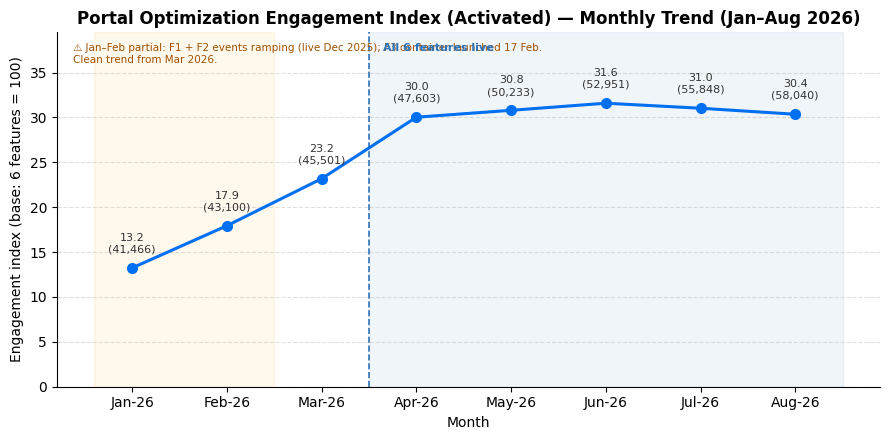

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

months_raw = df_f['month'].tolist()
months  = fmt_months(df_f['month'].tolist())
scores  = df_f['engagement_score_pct'].tolist()
ns      = df_f['n_suppliers'].tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(months, scores, marker='o', linewidth=2.2, markersize=7,
        color='#0070f3', zorder=3)

# annotate each point
for x, y, n in zip(months, scores, ns):
    ax.annotate(f'{y:.1f}\n({n:,})',
                xy=(x, y), xytext=(0, 11),
                textcoords='offset points', ha='center', fontsize=8,
                color='#333')

# structural break shading: Jan + Feb partial (F1/F2 ramp-up, F3 launch)
ax.axvspan(-0.4, 1.5, alpha=0.07, color='orange', zorder=0)
ax.text(0.02, 0.97,
        '⚠ Jan–Feb partial: F1 + F2 events ramping (live Dec 2025);'
        ' F3 container launched 17 Feb.\nClean trend from Mar 2026.',
        transform=ax.transAxes, fontsize=7.5, va='top', color='#a05000')

ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Engagement index (base: 6 features = 100)', fontsize=10)
ax.set_title('Portal Optimization Engagement Index (Activated) — Monthly Trend (Jan–Aug 2026)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(scores) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top','right']].set_visible(False)

mark_full_instr(ax, months_raw)
plt.tight_layout()
plt.show()


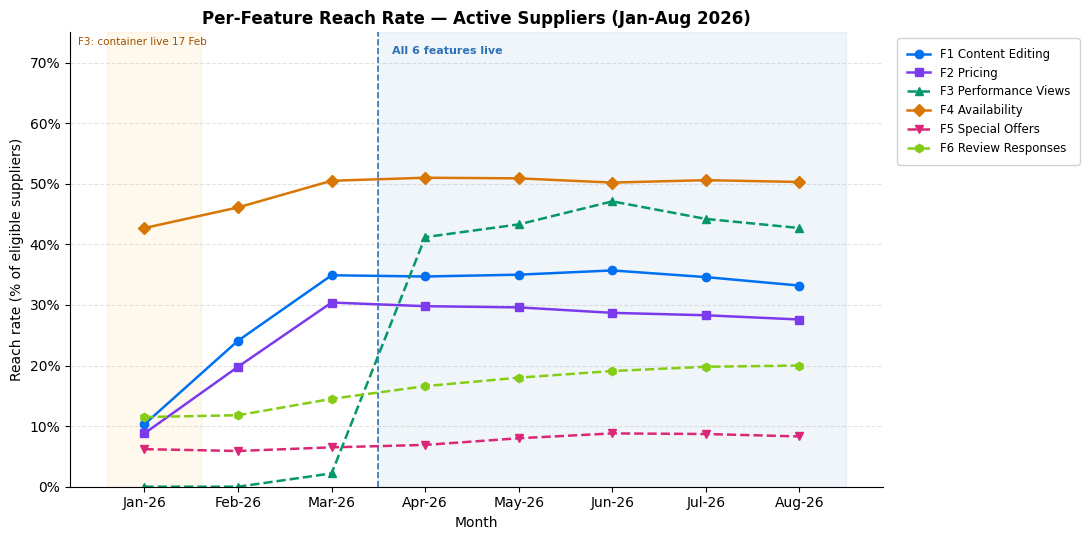

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

months_raw = df_f['month'].tolist()
months = fmt_months(df_f['month'].tolist())

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(months, df_f['f1_reach_pct'].tolist(), label='F1 Content Editing',   color='#0070f3', linestyle='-',  marker='o', linewidth=1.8, markersize=6)
ax.plot(months, df_f['f2_reach_pct'].tolist(), label='F2 Pricing',  color='#7c3aed', linestyle='-',  marker='s', linewidth=1.8, markersize=6)
ax.plot(months, df_f['f3_reach_pct'].tolist(), label='F3 Performance Views', color='#059669', linestyle='--', marker='^', linewidth=1.8, markersize=6)
ax.plot(months, df_f['f4_reach_pct'].tolist(), label='F4 Availability',      color='#d97706', linestyle='-',  marker='D', linewidth=1.8, markersize=6)
ax.plot(months, df_f['f5_reach_pct'].tolist(), label='F5 Special Offers',    color='#db2777', linestyle='--', marker='v', linewidth=1.8, markersize=6)
ax.plot(months, df_f['f6_reach_pct'].tolist(), label='F6 Review Responses',  color='#84cc16', linestyle='--', marker='h', linewidth=1.8, markersize=6)

# F3 structural break
ax.axvspan(-0.4, 0.6, alpha=0.07, color='orange', zorder=0)
ax.text(0.01, 0.99, 'F3: container live 17 Feb',
        transform=ax.transAxes, fontsize=7.5, va='top', color='#a05000')

ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Reach rate (% of eligible suppliers)', fontsize=10)
ax.set_title('Per-Feature Reach Rate — Active Suppliers (Jan-Aug 2026)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 75)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8.5,
          framealpha=0.9, borderpad=0.8)

mark_full_instr(ax, months_raw)
plt.tight_layout()
plt.show()


---
### Output G — Extended Engagement Trend (Jan 2025 - Jul 2026)

Headline score and per-feature reach rates across 19 months.  
Instrumentation notes:
- **F2 (Pricing):** feature existed throughout 2025 but the portal did not emit events for these actions before Dec 2025. Values before Dec 2025 are structurally zero, not true zero-usage.
- **F3 (Performance Views):** new feature. Container launched 17 Feb 2026. No data before Mar 2026.
- **Headline score Jan-Nov 2025** is understated due to missing F2 events (events not emitted before Dec 2025).


In [23]:
sql_trend_ext = '''
WITH months AS (
  SELECT
    DATE_FORMAT(mo, 'yyyy-MM') AS mo,
    mo                         AS mo_start,
    LAST_DAY(mo)               AS mo_end
  FROM (
    SELECT EXPLODE(SEQUENCE(DATE '2025-01-01', DATE '2026-08-01', INTERVAL 1 MONTH)) AS mo
  )
),
suppliers AS (
  SELECT m.mo, l.supplier_id
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
events AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2025-01-01' AND '2026-08-31'
),

sm AS (
  SELECT m.mo, m.mo_start, m.mo_end, s.supplier_id
  FROM months m JOIN suppliers s ON s.mo = m.mo
),
ff AS (
  SELECT sm.mo, sm.supplier_id,
    MAX(CASE WHEN e.container_name = 'ProductDetails'
             AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove',
      'PickupSaveArea','MeetingPointAddAddressButton',
      'PickupAddAreaButton','PickupAddAddressButton',
      'PickupSaveAddress','TourOptionSavedWithGeometry',
      'DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END) AS r1,
    MAX(CASE WHEN (e.container_name = 'ProductDetails'
      AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
      OR (e.container_name = 'availability-and-pricing'
          AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing'))
    THEN 1 ELSE 0 END) AS r2,
    -- F3 Performance Views — interaction-only
    MAX(CASE WHEN
      (e.container_name='SupplierPerformance' AND e.event_identifier IN (
        'FilterProducts','SupplierBusinessPerformanceDateRangeChange',
        'SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen',
        'SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick',
        'SupplierPerformanceByProductPageChange'))
      OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN (
        'SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange',
        'SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange'))
    THEN 1 ELSE 0 END) AS r3,
    MAX(CASE WHEN
      (e.container_name='SupplierAgenda' AND e.event_identifier IN
       ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff',
        'BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff'))
      OR (e.container_name='SupplierCalendar' AND e.event_identifier IN
       ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot',
        'CalendarUnblockTimeSlot','CalendarUnblockOption'))
      OR (e.container_name='availability-and-pricing' AND e.event_identifier IN
       ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule'))
      OR (e.container_name='ProductDetails'
          AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton'))
    THEN 1 ELSE 0 END) AS r4,
    MAX(CASE WHEN e.container_name='SupplierSpecialOffers'
      AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers')
    THEN 1 ELSE 0 END) AS r5,
    MAX(CASE WHEN e.container_name='SupplierReviews'
      AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END) AS r6
  FROM sm
  LEFT JOIN events e
    ON sm.supplier_id = e.supplier_id
   AND e.event_date BETWEEN sm.mo_start AND sm.mo_end
  GROUP BY sm.mo, sm.supplier_id
)
SELECT mo AS month,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(CAST(r1+r2+r3+r4+r5+r6 AS DOUBLE) / 6.0) * 100, 2) AS engagement_score_pct,
  ROUND(100.0 * SUM(r1) / COUNT(*), 1) AS f1_reach_pct,
  ROUND(100.0 * SUM(r2) / COUNT(*), 1) AS f2_reach_pct,
  ROUND(100.0 * SUM(r3) / COUNT(*), 1) AS f3_reach_pct,
  ROUND(100.0 * SUM(r4) / COUNT(*), 1) AS f4_reach_pct,
  ROUND(100.0 * SUM(r5) / COUNT(*), 1) AS f5_reach_pct,
  ROUND(100.0 * SUM(r6) / COUNT(*), 1) AS f6_reach_pct
FROM ff
GROUP BY mo
ORDER BY mo
'''
df_g = spark.sql(sql_trend_ext)
display(df_g)


,month,n_suppliers,engagement_score_pct,f1_reach_pct,f2_reach_pct,f3_reach_pct,f4_reach_pct,f5_reach_pct,f6_reach_pct
0,2025-01,33594,5.90,0.0,0.0,0.0,25.9,3.8,5.7
1,2025-02,33578,6.07,0.0,0.0,0.0,26.0,4.3,6.1
2,2025-03,34335,6.89,0.0,0.0,0.0,28.9,5.1,7.4
3,2025-04,34668,7.97,0.0,0.0,0.0,31.5,5.9,10.4
4,2025-05,35779,9.56,0.0,0.0,0.0,36.7,6.2,14.4
5,2025-06,36912,10.28,0.0,0.0,0.0,41.2,6.2,14.2
6,2025-07,36857,10.81,0.0,0.0,0.0,42.9,6.4,15.6
7,2025-08,37528,10.89,0.0,0.0,0.0,42.8,6.0,16.5
8,2025-09,38546,10.66,0.0,0.0,0.0,42.4,6.3,15.2
9,2025-10,38912,10.52,0.0,0.0,0.0,42.6,5.8,14.7


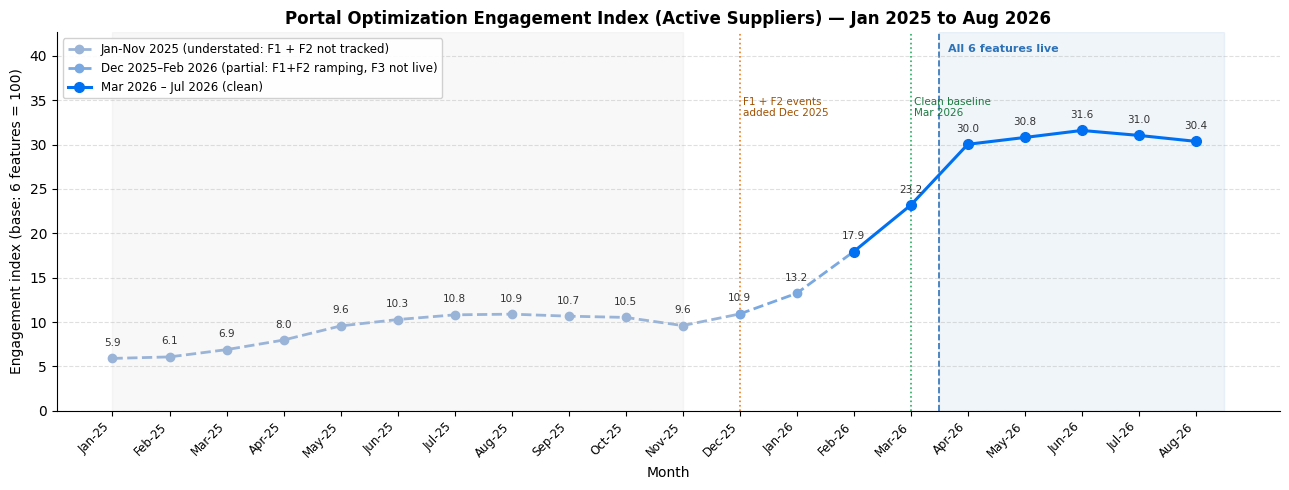

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

months_g = df_g['month'].tolist()
scores_g = df_g['engagement_score_pct'].tolist()
ns_g     = df_g['n_suppliers'].tolist()

# Index boundaries
# Jan-Nov 2025: indices 0-10  (understated — F1 + F2 not tracked)
# Dec 2025 – Jul 2026: indices 11-18
i_dec25 = months_g.index('2025-12')
i_mar26 = months_g.index('2026-03')

fig, ax = plt.subplots(figsize=(13, 5))

# Understated portion: Jan-Nov 2025 (include Dec so lines join)
ax.plot(months_g[:i_dec25 + 1], scores_g[:i_dec25 + 1],
        marker='o', linewidth=2, markersize=6,
        color='#9ab4d8', linestyle='--', zorder=3, label='Jan-Nov 2025 (understated: F1 + F2 not tracked)')

# Partial ramp portion: Dec 2025 – Feb 2026 (F1+F2 ramping, F3 not yet live)
i_feb26 = months_g.index('2026-02')
ax.plot(months_g[i_dec25:i_feb26 + 1], scores_g[i_dec25:i_feb26 + 1],
        marker='o', linewidth=2, markersize=6,
        color='#7aa8e0', linestyle='--', zorder=3, label='Dec 2025–Feb 2026 (partial: F1+F2 ramping, F3 not live)')

# Clean portion: Mar 2026 – Jul 2026
ax.plot(months_g[i_feb26:], scores_g[i_feb26:],
        marker='o', linewidth=2.2, markersize=7,
        color='#0070f3', linestyle='-', zorder=3, label='Mar 2026 – Jul 2026 (clean)')

# Annotate every point
for x, y, n in zip(months_g, scores_g, ns_g):
    ax.annotate(f'{y:.1f}',
                xy=(x, y), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=7.5, color='#333')

# Shading: understated region
ax.axvspan(months_g[0], months_g[i_dec25 - 1], alpha=0.06, color='#888', zorder=0)

# Structural break lines
ax.axvline(x=i_dec25, color='#e67e22', linewidth=1.2, linestyle=':', zorder=2)
ax.text(i_dec25 + 0.05, max(scores_g) * 1.12,
        'F1 + F2 events' + chr(10) + 'added Dec 2025', fontsize=7.5, color='#a05000', va='top')

ax.axvline(x=i_mar26, color='#27ae60', linewidth=1.2, linestyle=':', zorder=2)
ax.text(i_mar26 + 0.05, max(scores_g) * 1.12,
        'Clean baseline' + chr(10) + 'Mar 2026', fontsize=7.5, color='#1a7a40', va='top')

# Rotate x-axis labels
ax.set_xticks(range(len(months_g)))
ax.set_xticklabels(fmt_months(months_g), rotation=45, ha='right', fontsize=8.5)

ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Engagement index (base: 6 features = 100)', fontsize=10)
ax.set_title('Portal Optimization Engagement Index (Active Suppliers) — Jan 2025 to Aug 2026',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(scores_g) * 1.35)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

mark_full_instr(ax, months_g)
plt.tight_layout()
plt.show()


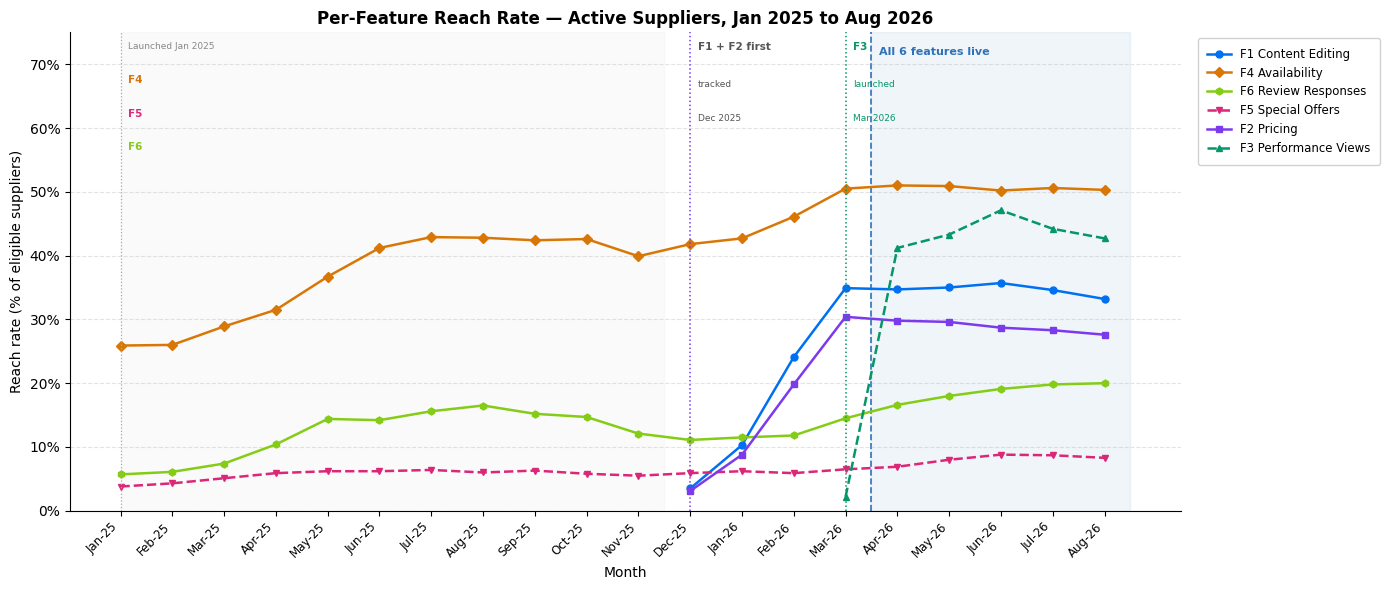

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.transforms import blended_transform_factory as btf

months_g = df_g['month'].tolist()

def mask_before(col, cutoff):
    return [None if m < cutoff else v for v, m in zip(df_g[col].tolist(), months_g)]

# F4, F5, F6: fully tracked from Jan 2025
# F1, F2: not tracked before Dec 2025 (existing product editor events went live then)
# F3: new feature, live from Mar 2026
f1 = mask_before('f1_reach_pct', '2025-12')
f2 = mask_before('f2_reach_pct', '2025-12')
f3 = mask_before('f3_reach_pct', '2026-03')
f4 = df_g['f4_reach_pct'].tolist()
f5 = df_g['f5_reach_pct'].tolist()
f6 = df_g['f6_reach_pct'].tolist()

i_jan25 = 0
i_dec25 = months_g.index('2025-12')
i_mar26 = months_g.index('2026-03')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(months_g, f1, label='F1 Content Editing',   color='#0070f3', marker='o',  linewidth=1.8, markersize=5)
ax.plot(months_g, f4, label='F4 Availability',       color='#d97706', marker='D',  linewidth=1.8, markersize=5)
ax.plot(months_g, f6, label='F6 Review Responses',   color='#84cc16', marker='h',  linewidth=1.8, markersize=5)
ax.plot(months_g, f5, label='F5 Special Offers',     color='#db2777', marker='v',  linewidth=1.8, markersize=5, linestyle='--')
ax.plot(months_g, f2, label='F2 Pricing',   color='#7c3aed', marker='s',  linewidth=1.8, markersize=5)
ax.plot(months_g, f3, label='F3 Performance Views',  color='#059669', marker='^',  linewidth=1.8, markersize=5, linestyle='--')

# Shading: period where F2 events are missing
ax.axvspan(0, i_dec25 - 0.5, alpha=0.04, color='#888')

# Blended transform: x in data coords, y in axes fraction (0=bottom, 1=top)
tr = btf(ax.transData, ax.transAxes)

# F4, F5, F6 — fully tracked from Jan 2025 (chart start)
ax.axvline(x=i_jan25, color='#aaa', linewidth=0.9, linestyle=':', zorder=2)
ax.text(i_jan25 + 0.15, 0.98, 'Launched Jan 2025', transform=tr,
        fontsize=6.5, color='#888', va='top', ha='left')
for label, color, yf in [
    ('F4', '#d97706', 0.91),
    ('F5', '#db2777', 0.84),
    ('F6', '#84cc16', 0.77),
]:
    ax.text(i_jan25 + 0.15, yf, label, transform=tr,
            fontsize=7.5, color=color, va='top', ha='left', fontweight='bold')

# F2 — events first tracked Dec 2025
ax.axvline(x=i_dec25, color='#7c3aed', linewidth=1.1, linestyle=':', zorder=2)
ax.text(i_dec25 + 0.15, 0.98, 'F1 + F2 first', transform=tr,
        fontsize=7.5, color='#555', va='top', ha='left', fontweight='bold')
ax.text(i_dec25 + 0.15, 0.90, 'tracked', transform=tr,
        fontsize=6.5, color='#555', va='top', ha='left')
ax.text(i_dec25 + 0.15, 0.83, 'Dec 2025', transform=tr,
        fontsize=6.5, color='#555', va='top', ha='left')

# F3 — feature launched Mar 2026
ax.axvline(x=i_mar26, color='#059669', linewidth=1.1, linestyle=':', zorder=2)
ax.text(i_mar26 + 0.15, 0.98, 'F3', transform=tr,
        fontsize=7.5, color='#059669', va='top', ha='left', fontweight='bold')
ax.text(i_mar26 + 0.15, 0.90, 'launched', transform=tr,
        fontsize=6.5, color='#059669', va='top', ha='left')
ax.text(i_mar26 + 0.15, 0.83, 'Mar 2026', transform=tr,
        fontsize=6.5, color='#059669', va='top', ha='left')

ax.set_xticks(range(len(months_g)))
ax.set_xticklabels(fmt_months(months_g), rotation=45, ha='right', fontsize=8.5)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Reach rate (% of eligible suppliers)', fontsize=10)
ax.set_title('Per-Feature Reach Rate — Active Suppliers, Jan 2025 to Aug 2026',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 75)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8.5,
          framealpha=0.9, borderpad=0.8)
mark_full_instr(ax, months_g)
plt.tight_layout()
plt.show()


---
### Output N — 3-Month Rolling Average Trend (Jan 2025 - Jul 2026)

Raw monthly scores respond to one-off campaigns and seasonal effects.
The 3-month rolling average smooths these out to show underlying platform engagement.
Use the rolling average for exec reporting; use the raw monthly for diagnosing individual months.

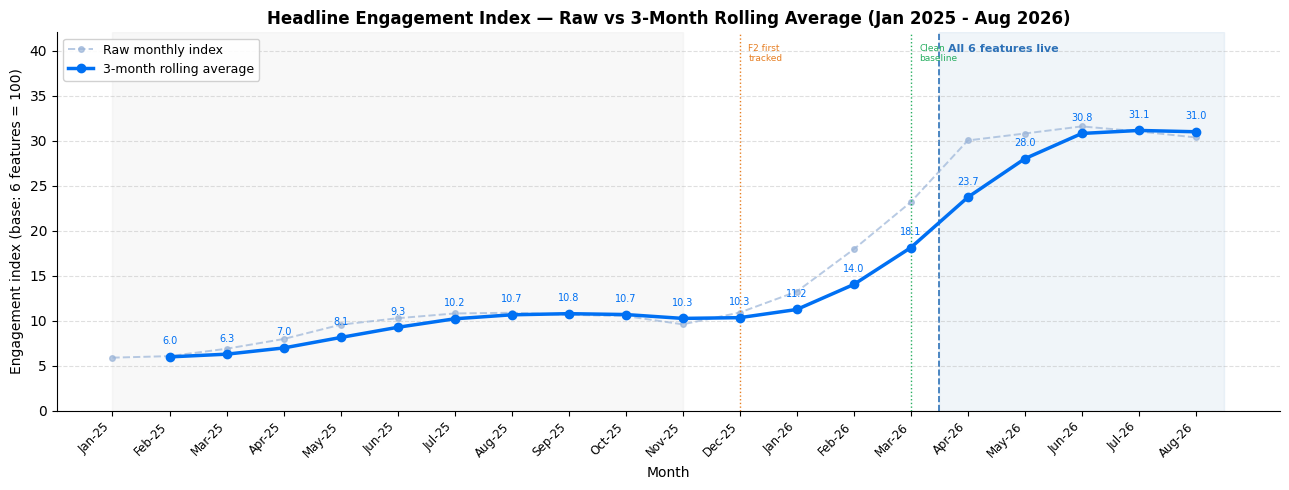

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.transforms import blended_transform_factory as btf
import pandas as pd

# Convert to pandas for rolling calculation
df_g_pd = (df_g.toPandas() if hasattr(df_g, 'toPandas') else df_g.copy()).sort_values('month').reset_index(drop=True)

months_g = df_g_pd['month'].tolist()
i_dec25 = months_g.index('2025-12')
i_mar26 = months_g.index('2026-03')

# Rolling 3-month average — headline
raw_score  = df_g_pd['engagement_score_pct']
roll_score = raw_score.rolling(3, min_periods=2).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Raw score (light)
ax.plot(months_g, raw_score, color='#9ab4d8', linewidth=1.4, linestyle='--',
        marker='o', markersize=4, label='Raw monthly index', alpha=0.7)

# Rolling average (bold)
ax.plot(months_g, roll_score, color='#0070f3', linewidth=2.5,
        marker='o', markersize=6, label='3-month rolling average', zorder=5)

# Annotate rolling average values
for x, y in zip(months_g, roll_score):
    if pd.notna(y):
        ax.annotate(f'{y:.1f}', xy=(x, y), xytext=(0, 9),
                    textcoords='offset points', ha='center', fontsize=7, color='#0070f3')

# Structural break lines
tr = btf(ax.transData, ax.transAxes)
ax.axvspan(months_g[0], months_g[i_dec25 - 1], alpha=0.05, color='#888', zorder=0)
ax.axvline(x=i_dec25, color='#e67e22', linewidth=1, linestyle=':', zorder=2)
ax.text(i_dec25 + 0.15, 0.97, 'F2 first\ntracked', transform=tr,
        fontsize=6.5, color='#e67e22', va='top')
ax.axvline(x=i_mar26, color='#27ae60', linewidth=1, linestyle=':', zorder=2)
ax.text(i_mar26 + 0.15, 0.97, 'Clean\nbaseline', transform=tr,
        fontsize=6.5, color='#27ae60', va='top')

ax.set_xticks(range(len(months_g)))
ax.set_xticklabels(fmt_months(months_g), rotation=45, ha='right', fontsize=8.5)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Engagement index (base: 6 features = 100)', fontsize=10)
ax.set_title('Headline Engagement Index — Raw vs 3-Month Rolling Average (Jan 2025 - Aug 2026)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(roll_score.dropna()) * 1.35)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
mark_full_instr(ax, months_g)
plt.tight_layout()
plt.show()

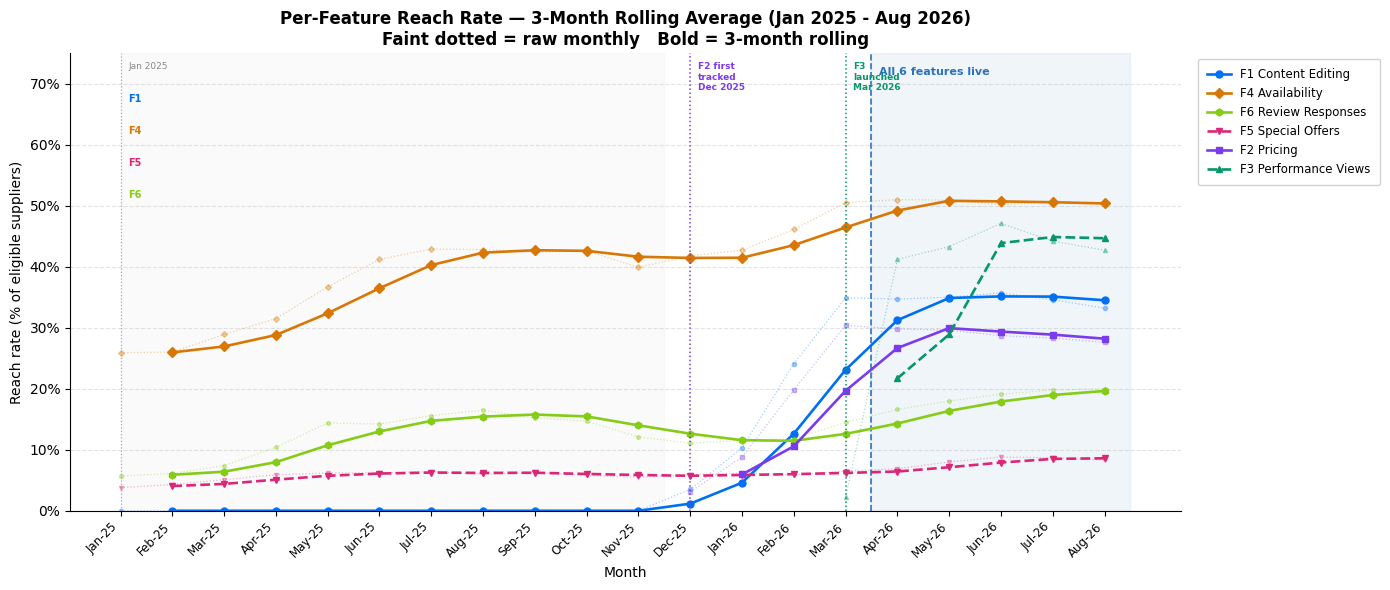

In [27]:
# Per-feature rolling average
# Mask pre-instrumentation periods before computing rolling (avoid averaging in structural zeros)
df_roll = df_g_pd.copy()
df_roll.loc[df_roll['month'] < '2025-12', 'f2_reach_pct'] = float('nan')
df_roll.loc[df_roll['month'] < '2026-03', 'f3_reach_pct'] = float('nan')

features = [
    ('f1_reach_pct', 'F1 Content Editing',   '#0070f3', 'o',  '-'),
    ('f4_reach_pct', 'F4 Availability',       '#d97706', 'D',  '-'),
    ('f6_reach_pct', 'F6 Review Responses',   '#84cc16', 'h',  '-'),
    ('f5_reach_pct', 'F5 Special Offers',     '#db2777', 'v',  '--'),
    ('f2_reach_pct', 'F2 Pricing',   '#7c3aed', 's',  '-'),
    ('f3_reach_pct', 'F3 Performance Views',  '#059669', '^',  '--'),
]

fig, ax = plt.subplots(figsize=(14, 6))

for col, label, color, marker, ls in features:
    raw  = df_roll[col]
    roll = raw.rolling(3, min_periods=2).mean()
    # Raw: faint dashed
    ax.plot(months_g, raw,  color=color, linewidth=0.9, linestyle=':', alpha=0.35, marker=marker, markersize=3)
    # Rolling: solid bold
    ax.plot(months_g, roll, color=color, linewidth=1.9, linestyle=ls,  marker=marker, markersize=5,
            label=label)

# Feature launch lines
tr = btf(ax.transData, ax.transAxes)
ax.axvline(x=0,       color='#aaa',    linewidth=0.9, linestyle=':', zorder=2)
ax.text(0.15, 0.98, 'Jan 2025', transform=tr, fontsize=6.5, color='#888', va='top')
for lbl, col, yf in [('F1','#0070f3',0.91),('F4','#d97706',0.84),
                      ('F5','#db2777',0.77),('F6','#84cc16',0.70)]:
    ax.text(0.15, yf, lbl, transform=tr, fontsize=7, color=col, va='top', fontweight='bold')

ax.axvspan(0, i_dec25 - 0.5, alpha=0.04, color='#888')
ax.axvline(x=i_dec25, color='#7c3aed', linewidth=1.1, linestyle=':', zorder=2)
ax.text(i_dec25 + 0.15, 0.98, 'F2 first\ntracked\nDec 2025', transform=tr,
        fontsize=6.5, color='#7c3aed', va='top', fontweight='bold')
ax.axvline(x=i_mar26, color='#059669', linewidth=1.1, linestyle=':', zorder=2)
ax.text(i_mar26 + 0.15, 0.98, 'F3\nlaunched\nMar 2026', transform=tr,
        fontsize=6.5, color='#059669', va='top', fontweight='bold')

ax.set_xticks(range(len(months_g)))
ax.set_xticklabels(fmt_months(months_g), rotation=45, ha='right', fontsize=8.5)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Reach rate (% of eligible suppliers)', fontsize=10)
ax.set_title('Per-Feature Reach Rate — 3-Month Rolling Average (Jan 2025 - Aug 2026)\n'
             'Faint dotted = raw monthly   Bold = 3-month rolling',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 75)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8.5,
          framealpha=0.9, borderpad=0.8)
mark_full_instr(ax, months_g)
plt.tight_layout()
plt.show()

---
### Output H — Engagement by GMV tier (July 2026)

Restated on the new active supplier definition (bookable + booked any day in month).
GMV = `gmv_eur_l365` from the July 31 snapshot of `agg_supplier_lifecycle_daily`.

Tiers: €0 (no GMV in last 365 days), €1–10K, €10K–50K, €50K–100K, €100K+.

In [28]:
sql_gmv = '''
WITH base AS (
  SELECT
    e.supplier_id,
    e.supplier_engagement_share,
    COALESCE(l.gmv_eur_l365, 0) AS gmv_eur_l365
  FROM v_supplier_engagement e
  LEFT JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.supplier_id = e.supplier_id
   AND l.snapshot_date = '2026-08-31'
),
tiered AS (
  SELECT
    supplier_id,
    supplier_engagement_share,
    gmv_eur_l365,
    CASE
      WHEN gmv_eur_l365 = 0       THEN '1_zero'
      WHEN gmv_eur_l365 < 10000   THEN '2_1_to_10k'
      WHEN gmv_eur_l365 < 50000   THEN '3_10k_to_50k'
      WHEN gmv_eur_l365 < 100000  THEN '4_50k_to_100k'
      ELSE                             '5_100k_plus'
    END AS gmv_tier
  FROM base
)
SELECT
  CASE gmv_tier
    WHEN '1_zero'        THEN '\u20ac0'
    WHEN '2_1_to_10k'    THEN '\u20ac1 to \u20ac10K'
    WHEN '3_10k_to_50k'  THEN '\u20ac10K to \u20ac50K'
    WHEN '4_50k_to_100k' THEN '\u20ac50K to \u20ac100K'
    ELSE '\u20ac100K+'
  END AS gmv_tier_label,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS avg_engagement_pct,
  ROUND(AVG(gmv_eur_l365), 0) AS avg_gmv_eur
FROM tiered
GROUP BY gmv_tier, gmv_tier_label
ORDER BY gmv_tier
'''

df_h = spark.sql(sql_gmv)
display(df_h)

,gmv_tier_label,n_suppliers,avg_engagement_pct,avg_gmv_eur
0,€0,195,6.0,0
1,€1 to €10K,35517,24.1,2432
2,€10K to €50K,11748,35.8,23663
3,€50K to €100K,3716,41.4,70858
4,€100K+,6864,48.3,567087


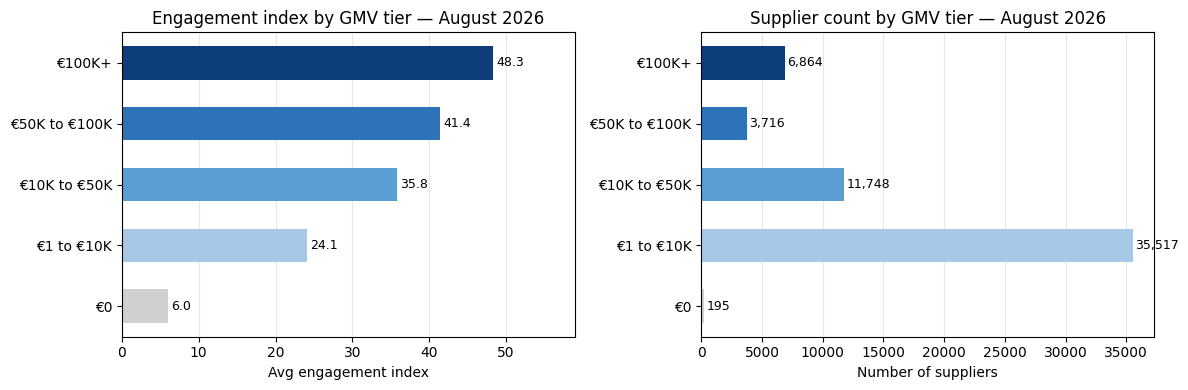

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_h_pd = df_h.toPandas() if hasattr(df_h, 'toPandas') else df_h.copy()
df_h_pd['avg_engagement_pct'] = df_h_pd['avg_engagement_pct'].astype(float)
df_h_pd['n_suppliers'] = df_h_pd['n_suppliers'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tier_colors = ['#d0d0d0', '#a8c8e8', '#5a9fd4', '#2e72b8', '#0d3d7a']

bars = axes[0].barh(df_h_pd['gmv_tier_label'], df_h_pd['avg_engagement_pct'],
                    color=tier_colors[:len(df_h_pd)], height=0.55)
for bar, val in zip(bars, df_h_pd['avg_engagement_pct']):
    axes[0].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontsize=9)
axes[0].set_xlabel('Avg engagement index')
axes[0].set_title('Engagement index by GMV tier — August 2026')
axes[0].set_xlim(0, max(df_h_pd['avg_engagement_pct']) * 1.22)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_axisbelow(True)

bars2 = axes[1].barh(df_h_pd['gmv_tier_label'], df_h_pd['n_suppliers'],
                     color=tier_colors[:len(df_h_pd)], height=0.55)
for bar, val in zip(bars2, df_h_pd['n_suppliers']):
    axes[1].text(val + 200, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of suppliers')
axes[1].set_title('Supplier count by GMV tier — August 2026')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


---
### Output I — Engagement index distribution (July 2026)

Distribution of suppliers by number of features reached (0–6) and percentile table.
Validates whether the average is a meaningful summary statistic or masks a skewed distribution.

In [30]:
# Distribution: count of features reached
df_i_dist = spark.sql('''
SELECT
  n_features_reached,
  COUNT(*) AS n_suppliers,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_suppliers
FROM v_supplier_engagement
GROUP BY n_features_reached
ORDER BY n_features_reached
''')
display(df_i_dist)

# Percentile table
df_i_pct = spark.sql('''
SELECT
  ROUND(percentile_approx(supplier_engagement_share * 100, 0.10), 1) AS p10,
  ROUND(percentile_approx(supplier_engagement_share * 100, 0.25), 1) AS p25,
  ROUND(percentile_approx(supplier_engagement_share * 100, 0.50), 1) AS p50,
  ROUND(percentile_approx(supplier_engagement_share * 100, 0.75), 1) AS p75,
  ROUND(percentile_approx(supplier_engagement_share * 100, 0.90), 1) AS p90,
  ROUND(AVG(supplier_engagement_share * 100), 1) AS mean_pct
FROM v_supplier_engagement
''')
display(df_i_pct)

,n_features_reached,n_suppliers,pct_suppliers
0,0,20538,35.4
1,1,10663,18.4
2,2,6736,11.6
3,3,6436,11.1
4,4,7470,12.9
5,5,4776,8.2
6,6,1421,2.4


,p10,p25,p50,p75,p90,mean_pct
0,0.0,0.0,16.7,50.0,83.3,30.4


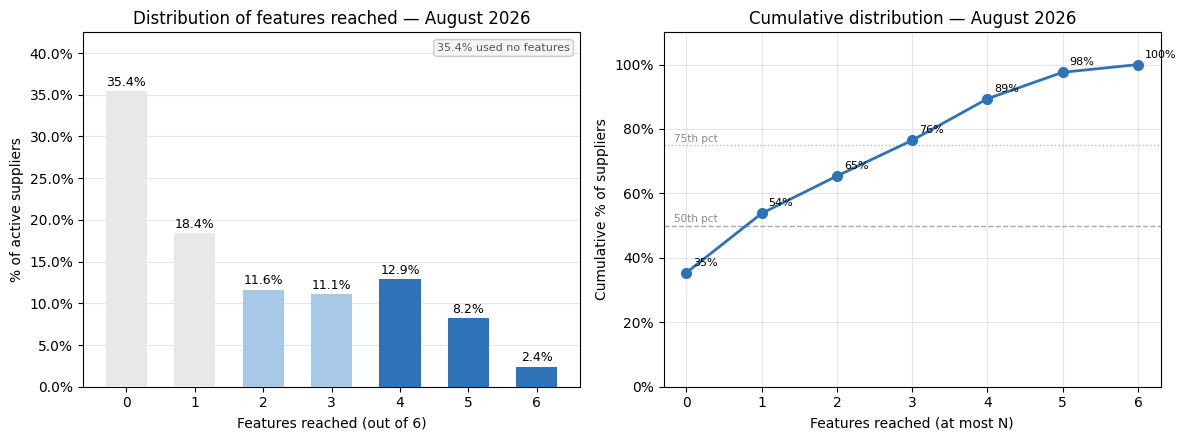

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df_i_pd = df_i_dist.toPandas() if hasattr(df_i_dist, 'toPandas') else df_i_dist.copy()
df_i_pd['pct_suppliers'] = df_i_pd['pct_suppliers'].astype(float)
df_i_pd['n_features_reached'] = df_i_pd['n_features_reached'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar_colors = ['#e8e8e8' if x < 2 else '#a8c8e8' if x < 4 else '#2e72b8'
              for x in df_i_pd['n_features_reached']]
bars = axes[0].bar(df_i_pd['n_features_reached'].astype(str),
                   df_i_pd['pct_suppliers'], color=bar_colors, width=0.6, zorder=3)
for bar, val in zip(bars, df_i_pd['pct_suppliers']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Features reached (out of 6)')
axes[0].set_ylabel('% of active suppliers')
axes[0].set_title('Distribution of features reached — August 2026')
axes[0].set_ylim(0, max(df_i_pd['pct_suppliers']) * 1.2)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

zero_pct = df_i_pd.loc[df_i_pd['n_features_reached'] == 0, 'pct_suppliers']
if not zero_pct.empty:
    axes[0].text(0.98, 0.97, f"{zero_pct.values[0]:.1f}% used no features",
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
                 color='#555', bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#ccc'))

# Cumulative distribution
cumsum = np.cumsum(df_i_pd['pct_suppliers'].values)
xs = df_i_pd['n_features_reached'].values
axes[1].plot(xs, cumsum, marker='o', linewidth=2, markersize=7, color='#2e72b8', zorder=3)
for x, y in zip(xs, cumsum):
    axes[1].annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].axhline(50, color='#aaa', linestyle='--', linewidth=1)
axes[1].text(0.02, 51, '50th pct', transform=axes[1].get_yaxis_transform(), fontsize=7.5, color='#888')
axes[1].axhline(75, color='#bbb', linestyle=':', linewidth=1)
axes[1].text(0.02, 76, '75th pct', transform=axes[1].get_yaxis_transform(), fontsize=7.5, color='#888')
axes[1].set_xlabel('Features reached (at most N)')
axes[1].set_ylabel('Cumulative % of suppliers')
axes[1].set_title('Cumulative distribution — August 2026')
axes[1].set_ylim(0, 110)
axes[1].set_xticks(xs)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


---
### Output J — Feature co-usage matrix (July 2026)

For each feature (row = suppliers who used it), the % who also used each other feature.
Compare each cell to the overall reach rate of the column feature — a value much higher than the
baseline suggests co-adoption clustering, not independent signal.

In [32]:
df_j = spark.sql('''
WITH scored AS (
  SELECT
    CASE WHEN f1_content_editing   = 'eligible_reached' THEN 1 ELSE 0 END AS f1,
    CASE WHEN f2_option_pricing    = 'eligible_reached' THEN 1 ELSE 0 END AS f2,
    CASE WHEN f3_performance_views = 'eligible_reached' THEN 1 ELSE 0 END AS f3,
    CASE WHEN f4_availability      = 'eligible_reached' THEN 1 ELSE 0 END AS f4,
    CASE WHEN f5_special_offers    = 'eligible_reached' THEN 1 ELSE 0 END AS f5,
    CASE WHEN f6_review_replies    = 'eligible_reached' THEN 1 ELSE 0 END AS f6
  FROM v_supplier_engagement
),
-- overall reach rates (baseline row for comparison)
baseline AS (
  SELECT '0 — ALL suppliers' AS used_feature,
    ROUND(100.0 * SUM(f1) / COUNT(*), 1) AS also_f1,
    ROUND(100.0 * SUM(f2) / COUNT(*), 1) AS also_f2,
    ROUND(100.0 * SUM(f3) / COUNT(*), 1) AS also_f3,
    ROUND(100.0 * SUM(f4) / COUNT(*), 1) AS also_f4,
    ROUND(100.0 * SUM(f5) / COUNT(*), 1) AS also_f5,
    ROUND(100.0 * SUM(f6) / COUNT(*), 1) AS also_f6,
    COUNT(*) AS n
  FROM scored
),
rows AS (
  SELECT 'F1 Content Editing' AS used_feature,
    ROUND(100.0 * SUM(f1) / COUNT(*), 1) AS also_f1,
    ROUND(100.0 * SUM(f2) / COUNT(*), 1) AS also_f2,
    ROUND(100.0 * SUM(f3) / COUNT(*), 1) AS also_f3,
    ROUND(100.0 * SUM(f4) / COUNT(*), 1) AS also_f4,
    ROUND(100.0 * SUM(f5) / COUNT(*), 1) AS also_f5,
    ROUND(100.0 * SUM(f6) / COUNT(*), 1) AS also_f6,
    COUNT(*) AS n
  FROM scored WHERE f1=1
  UNION ALL
  SELECT 'F2 Pricing', ROUND(100.0*SUM(f1)/COUNT(*),1), ROUND(100.0*SUM(f2)/COUNT(*),1),
    ROUND(100.0*SUM(f3)/COUNT(*),1), ROUND(100.0*SUM(f4)/COUNT(*),1),
    ROUND(100.0*SUM(f5)/COUNT(*),1), ROUND(100.0*SUM(f6)/COUNT(*),1), COUNT(*)
  FROM scored WHERE f2=1
  UNION ALL
  SELECT 'F3 Performance Views', ROUND(100.0*SUM(f1)/COUNT(*),1), ROUND(100.0*SUM(f2)/COUNT(*),1),
    ROUND(100.0*SUM(f3)/COUNT(*),1), ROUND(100.0*SUM(f4)/COUNT(*),1),
    ROUND(100.0*SUM(f5)/COUNT(*),1), ROUND(100.0*SUM(f6)/COUNT(*),1), COUNT(*)
  FROM scored WHERE f3=1
  UNION ALL
  SELECT 'F4 Availability', ROUND(100.0*SUM(f1)/COUNT(*),1), ROUND(100.0*SUM(f2)/COUNT(*),1),
    ROUND(100.0*SUM(f3)/COUNT(*),1), ROUND(100.0*SUM(f4)/COUNT(*),1),
    ROUND(100.0*SUM(f5)/COUNT(*),1), ROUND(100.0*SUM(f6)/COUNT(*),1), COUNT(*)
  FROM scored WHERE f4=1
  UNION ALL
  SELECT 'F5 Special Offers', ROUND(100.0*SUM(f1)/COUNT(*),1), ROUND(100.0*SUM(f2)/COUNT(*),1),
    ROUND(100.0*SUM(f3)/COUNT(*),1), ROUND(100.0*SUM(f4)/COUNT(*),1),
    ROUND(100.0*SUM(f5)/COUNT(*),1), ROUND(100.0*SUM(f6)/COUNT(*),1), COUNT(*)
  FROM scored WHERE f5=1
  UNION ALL
  SELECT 'F6 Review Responses', ROUND(100.0*SUM(f1)/COUNT(*),1), ROUND(100.0*SUM(f2)/COUNT(*),1),
    ROUND(100.0*SUM(f3)/COUNT(*),1), ROUND(100.0*SUM(f4)/COUNT(*),1),
    ROUND(100.0*SUM(f5)/COUNT(*),1), ROUND(100.0*SUM(f6)/COUNT(*),1), COUNT(*)
  FROM scored WHERE f6=1
)
SELECT * FROM baseline
UNION ALL
SELECT * FROM rows
ORDER BY used_feature
''')
display(df_j)

,used_feature,also_f1,also_f2,also_f3,also_f4,also_f5,also_f6,n
0,0 — ALL suppliers,33.2,27.6,42.7,50.3,8.3,20.0,58040
1,F1 Content Editing,100.0,78.4,72.4,95.4,19.6,34.8,19245
2,F2 Pricing,94.1,100.0,72.6,100.0,20.6,35.0,16046
3,F3 Performance Views,56.2,47.0,100.0,74.1,15.7,33.5,24797
4,F4 Availability,62.9,54.9,62.9,100.0,14.5,29.7,29204
5,F5 Special Offers,78.5,68.8,81.0,88.1,100.0,42.0,4801
6,F6 Review Responses,57.5,48.3,71.3,74.6,17.3,100.0,11636


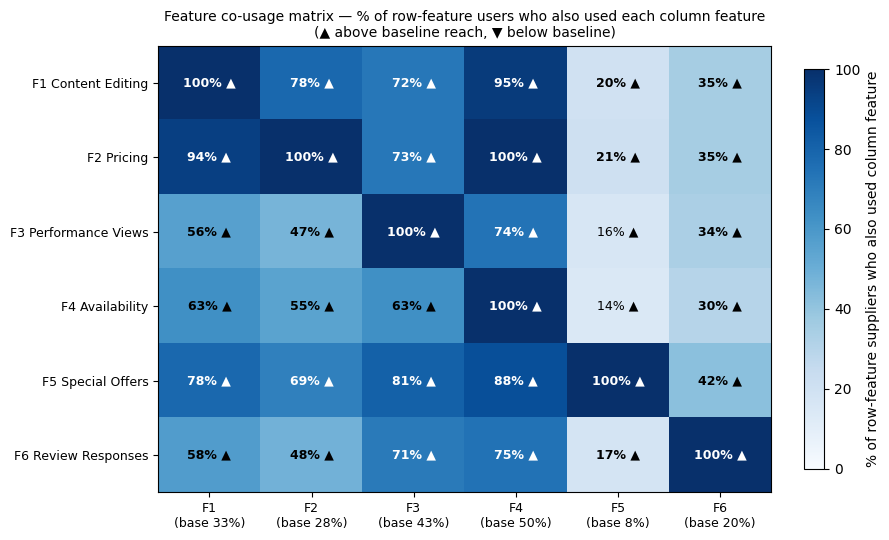

In [33]:
import matplotlib.pyplot as plt
import numpy as np

df_j_pd = df_j.toPandas() if hasattr(df_j, 'toPandas') else df_j.copy()
for c in ['also_f1','also_f2','also_f3','also_f4','also_f5','also_f6']:
    df_j_pd[c] = df_j_pd[c].astype(float)

feature_order = ['F1 Content Editing', 'F2 Pricing', 'F3 Performance Views',
                 'F4 Availability', 'F5 Special Offers', 'F6 Review Responses']
col_keys   = ['also_f1', 'also_f2', 'also_f3', 'also_f4', 'also_f5', 'also_f6']
col_labels = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6']

base_row = df_j_pd[df_j_pd['used_feature'] == '0 — ALL suppliers']
baseline = np.array([float(base_row[c].values[0]) for c in col_keys]) if not base_row.empty else np.zeros(6)

matrix, row_labels = [], []
for feat in feature_order:
    row = df_j_pd[df_j_pd['used_feature'] == feat]
    if not row.empty:
        matrix.append([float(row[c].values[0]) for c in col_keys])
        row_labels.append(feat)
matrix = np.array(matrix)

fig, ax = plt.subplots(figsize=(9, 5.5))
im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=100, aspect='auto')

for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = matrix[i, j]
        diff = val - baseline[j]
        text_color = 'white' if val > 65 else 'black'
        marker = '' if abs(diff) < 3 else (' ▲' if diff > 0 else ' ▼')
        weight = 'bold' if abs(diff) > 8 else 'normal'
        ax.text(j, i, f'{val:.0f}%{marker}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight=weight)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(
    [f'{c}\n(base {b:.0f}%)' for c, b in zip(col_labels, baseline)], fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title('Feature co-usage matrix — % of row-feature users who also used each column feature\n'
             '(▲ above baseline reach, ▼ below baseline)', fontsize=10)
plt.colorbar(im, ax=ax, label='% of row-feature suppliers who also used column feature', fraction=0.03)
plt.tight_layout()
plt.show()


---
### Output K — Engagement by segment (July 2026)

Three cuts: managed vs non-managed, size tier (S/M/L/XL), supplier segment.
`is_managed`, `size_tier`, `supplier_segment` from `agg_supplier_lifecycle_daily` at 2026-08-31.

If managed suppliers score materially higher, the metric may be partly measuring account management
intensity rather than portal value delivery.

In [34]:
_seg_join = '''
  LEFT JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.supplier_id = e.supplier_id AND l.snapshot_date = '2026-08-31'
'''

# Managed vs non-managed — full per-feature breakdown
df_k_managed = spark.sql(f'''
WITH base AS (
  SELECT
    e.supplier_id,
    e.supplier_engagement_share,
    CASE WHEN f1_content_editing   = 'eligible_reached' THEN 1 ELSE 0 END AS f1,
    CASE WHEN f2_option_pricing    = 'eligible_reached' THEN 1 ELSE 0 END AS f2,
    CASE WHEN f3_performance_views = 'eligible_reached' THEN 1 ELSE 0 END AS f3,
    CASE WHEN f4_availability      = 'eligible_reached' THEN 1 ELSE 0 END AS f4,
    CASE WHEN f5_special_offers    = 'eligible_reached' THEN 1 ELSE 0 END AS f5,
    CASE WHEN f6_review_replies    = 'eligible_reached' THEN 1 ELSE 0 END AS f6,
    COALESCE(CAST(l.is_managed AS STRING), 'unknown') AS is_managed
  FROM v_supplier_engagement e
  {_seg_join}
)
SELECT
  is_managed,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS avg_engagement_pct,
  ROUND(100.0 * SUM(f1) / COUNT(*), 1) AS f1_reach,
  ROUND(100.0 * SUM(f2) / COUNT(*), 1) AS f2_reach,
  ROUND(100.0 * SUM(f3) / COUNT(*), 1) AS f3_reach,
  ROUND(100.0 * SUM(f4) / COUNT(*), 1) AS f4_reach,
  ROUND(100.0 * SUM(f5) / COUNT(*), 1) AS f5_reach,
  ROUND(100.0 * SUM(f6) / COUNT(*), 1) AS f6_reach
FROM base
GROUP BY is_managed ORDER BY is_managed
''')
display(df_k_managed)

# Size tier
df_k_tier = spark.sql(f'''
WITH base AS (
  SELECT e.supplier_id, e.supplier_engagement_share,
    COALESCE(NULLIF(l.size_tier, 'Inactive'), 'Inactive') AS size_tier
  FROM v_supplier_engagement e
  {_seg_join}
)
SELECT size_tier, COUNT(*) AS n_suppliers,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS avg_engagement_pct
FROM base
GROUP BY size_tier ORDER BY
  CASE size_tier WHEN 'S' THEN 1 WHEN 'M' THEN 2 WHEN 'L' THEN 3 WHEN 'XL' THEN 4 ELSE 5 END
''')
display(df_k_tier)

# Supplier segment
df_k_seg = spark.sql(f'''
WITH base AS (
  SELECT e.supplier_id, e.supplier_engagement_share,
    COALESCE(NULLIF(l.supplier_segment, ''), 'Unknown') AS supplier_segment
  FROM v_supplier_engagement e
  {_seg_join}
)
SELECT supplier_segment, COUNT(*) AS n_suppliers,
  ROUND(AVG(supplier_engagement_share) * 100, 1) AS avg_engagement_pct
FROM base
GROUP BY supplier_segment ORDER BY avg_engagement_pct DESC
''')
display(df_k_seg)

,is_managed,n_suppliers,avg_engagement_pct,f1_reach,f2_reach,f3_reach,f4_reach,f5_reach,f6_reach
0,false,51904,29.0,31.4,26.2,40.8,49.0,8.0,18.6
1,true,6136,41.9,47.8,39.6,59.3,61.6,10.7,32.1


,size_tier,n_suppliers,avg_engagement_pct
0,S,50662,27.8
1,M,6314,47.3
2,L,733,60.2
3,XL,136,65.7
4,Inactive,195,6.0


,supplier_segment,n_suppliers,avg_engagement_pct
0,Unknown,8,47.9
1,Scale Seeker,32011,34.7
2,Independent Creator,24647,25.5
3,Leisure Brand,323,19.4
4,Heritage Preserver,1051,15.4


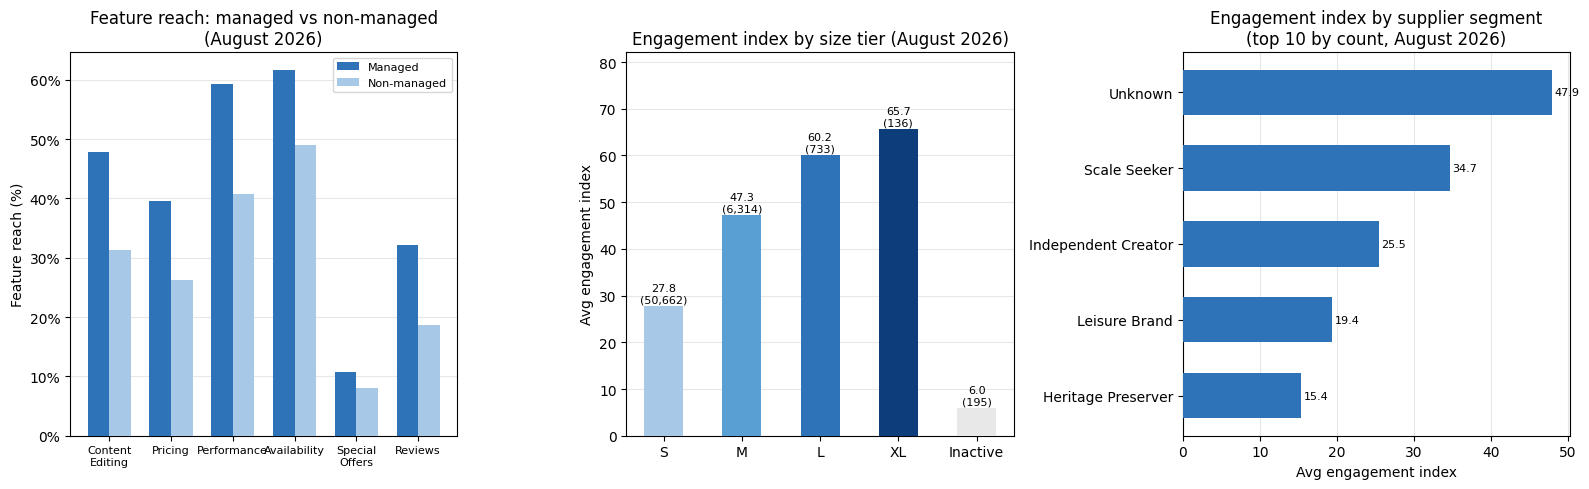

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_k_managed_pd = df_k_managed.toPandas() if hasattr(df_k_managed, 'toPandas') else df_k_managed.copy()
df_k_tier_pd    = df_k_tier.toPandas()    if hasattr(df_k_tier,    'toPandas') else df_k_tier.copy()
df_k_seg_pd     = df_k_seg.toPandas()     if hasattr(df_k_seg,     'toPandas') else df_k_seg.copy()

for df in [df_k_managed_pd, df_k_tier_pd, df_k_seg_pd]:
    for c in df.columns:
        if df[c].dtype == object:
            try:
                df[c] = df[c].astype(float)
            except (ValueError, TypeError):
                pass
        else:
            try:
                df[c] = df[c].astype(float)
            except (ValueError, TypeError):
                pass

feat_cols   = ['f1_reach', 'f2_reach', 'f3_reach', 'f4_reach', 'f5_reach', 'f6_reach']
feat_labels = ['Content\nEditing', 'Pricing', 'Performance', 'Availability', 'Special\nOffers', 'Reviews']
x = list(range(len(feat_labels)))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

managed_row     = df_k_managed_pd[df_k_managed_pd['is_managed'].astype(str) == 'true']
non_managed_row = df_k_managed_pd[df_k_managed_pd['is_managed'].astype(str) == 'false']

if not managed_row.empty and not non_managed_row.empty:
    axes[0].bar([i - width / 2 for i in x],
                [float(managed_row[c].values[0]) for c in feat_cols],
                width, label='Managed', color='#2e72b8', zorder=3)
    axes[0].bar([i + width / 2 for i in x],
                [float(non_managed_row[c].values[0]) for c in feat_cols],
                width, label='Non-managed', color='#a8c8e8', zorder=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(feat_labels, fontsize=8)
    axes[0].legend(fontsize=8)
else:
    axes[0].bar(df_k_managed_pd['is_managed'].astype(str),
                df_k_managed_pd['avg_engagement_pct'].astype(float), color='#2e72b8')
axes[0].set_ylabel('Feature reach (%)')
axes[0].set_title('Feature reach: managed vs non-managed\n(August 2026)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

tier_colors = ['#a8c8e8', '#5a9fd4', '#2e72b8', '#0d3d7a', '#e8e8e8']
eng_vals = df_k_tier_pd['avg_engagement_pct'].astype(float)
n_vals   = df_k_tier_pd['n_suppliers'].astype(int)
bars = axes[1].bar(df_k_tier_pd['size_tier'].astype(str), eng_vals,
                   color=tier_colors[:len(df_k_tier_pd)], width=0.5, zorder=3)
for bar, val, n in zip(bars, eng_vals, n_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}\n({n:,})', ha='center', va='bottom', fontsize=8)
axes[1].set_ylabel('Avg engagement index')
axes[1].set_title('Engagement index by size tier (August 2026)')
axes[1].set_ylim(0, max(eng_vals) * 1.25)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

top_seg = df_k_seg_pd.copy()
top_seg['avg_engagement_pct'] = top_seg['avg_engagement_pct'].astype(float)
top_seg['n_suppliers'] = top_seg['n_suppliers'].astype(int)
top_seg = top_seg.nlargest(10, 'n_suppliers').sort_values('avg_engagement_pct')
bars2 = axes[2].barh(top_seg['supplier_segment'].astype(str), top_seg['avg_engagement_pct'],
                     color='#2e72b8', height=0.6, zorder=3)
for bar, val in zip(bars2, top_seg['avg_engagement_pct']):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontsize=8)
axes[2].set_xlabel('Avg engagement index')
axes[2].set_title('Engagement index by supplier segment\n(top 10 by count, August 2026)')
axes[2].grid(axis='x', alpha=0.3)
axes[2].set_axisbelow(True)

plt.tight_layout()
plt.show()


---
### Output N — Segment trends (Jan 2025 to Aug 2026)

The segment charts above are single-month snapshots. These show the same cuts over the clean window so the direction is visible, which is what matters for target setting.


In [36]:
sql_seg_trend = """
WITH months AS (
  SELECT DATE_FORMAT(mo,'yyyy-MM') AS mo, mo AS mo_start, LAST_DAY(mo) AS mo_end
  FROM (SELECT EXPLODE(SEQUENCE(DATE '2025-01-01', DATE '2026-08-01', INTERVAL 1 MONTH)) AS mo)
),
sup AS (
  SELECT m.mo, m.mo_start, m.mo_end, l.supplier_id,
         MAX(CASE WHEN l.is_managed THEN 1 ELSE 0 END) AS is_managed,
         MAX(COALESCE(l.gmv_eur_l365,0))               AS gmv_l365
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, m.mo_start, m.mo_end, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
ev AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2025-01-01' AND '2026-08-31'
),
scored AS (
  SELECT s.mo, s.supplier_id, s.is_managed, s.gmv_l365, CAST(
      MAX(CASE WHEN e.container_name='ProductDetails' AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove','PickupSaveArea','MeetingPointAddAddressButton','PickupAddAreaButton','PickupAddAddressButton','PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierPerformance' AND e.event_identifier IN ('FilterProducts','SupplierBusinessPerformanceDateRangeChange','SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen','SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick','SupplierPerformanceByProductPageChange')) OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN ('SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange','SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierAgenda' AND e.event_identifier IN ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff','BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff')) OR (e.container_name='SupplierCalendar' AND e.event_identifier IN ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot','CalendarUnblockTimeSlot','CalendarUnblockOption')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule')) OR (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierSpecialOffers' AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierReviews' AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END)
  AS INT) AS n_feat
  FROM sup s LEFT JOIN ev e
    ON e.supplier_id = s.supplier_id AND e.event_date BETWEEN s.mo_start AND s.mo_end
  GROUP BY s.mo, s.supplier_id, s.is_managed, s.gmv_l365
)
SELECT mo,
  CASE WHEN gmv_l365 = 0 THEN '1 No GMV' WHEN gmv_l365 < 10000 THEN '2 Under 10K'
       WHEN gmv_l365 < 50000 THEN '3 10K-50K' WHEN gmv_l365 < 100000 THEN '4 50K-100K'
       ELSE '5 Over 100K' END AS gmv_tier,
  is_managed,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(CAST(n_feat AS DOUBLE)/6.0)*100, 2) AS engagement_index,
  ROUND(100.0*SUM(CASE WHEN n_feat = 0 THEN 1 ELSE 0 END)/COUNT(*), 2) AS pct_zero
FROM scored GROUP BY mo, gmv_tier, is_managed ORDER BY mo, gmv_tier, is_managed
"""
df_n = spark.sql(sql_seg_trend)
display(df_n.head(15))


,mo,gmv_tier,is_managed,n_suppliers,engagement_index,pct_zero
0,2025-01,1 No GMV,0,59,3.95,79.66
1,2025-01,2 Under 10K,0,19078,4.27,76.72
2,2025-01,2 Under 10K,1,359,5.94,67.41
3,2025-01,3 10K-50K,0,6532,7.05,62.78
4,2025-01,3 10K-50K,1,670,8.93,57.31
5,2025-01,4 50K-100K,0,1878,8.05,58.73
6,2025-01,4 50K-100K,1,539,8.38,58.63
7,2025-01,5 Over 100K,0,1707,9.76,52.90
8,2025-01,5 Over 100K,1,2772,9.34,54.44
9,2025-02,1 No GMV,0,50,3.67,82.00


/var/folders/9d/hcf377nd3rn6bdg7t5mjpmtc0000gp/T/ipykernel_11439/2397047934.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = d[d['gmv_tier']==tier].groupby('mo').apply(wavg).reindex(order)
/var/folders/9d/hcf377nd3rn6bdg7t5mjpmtc0000gp/T/ipykernel_11439/2397047934.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = d[d['gmv_tier']==tier].groupby('mo').apply(wavg).reindex(order)
/var/folders/9d/hcf377

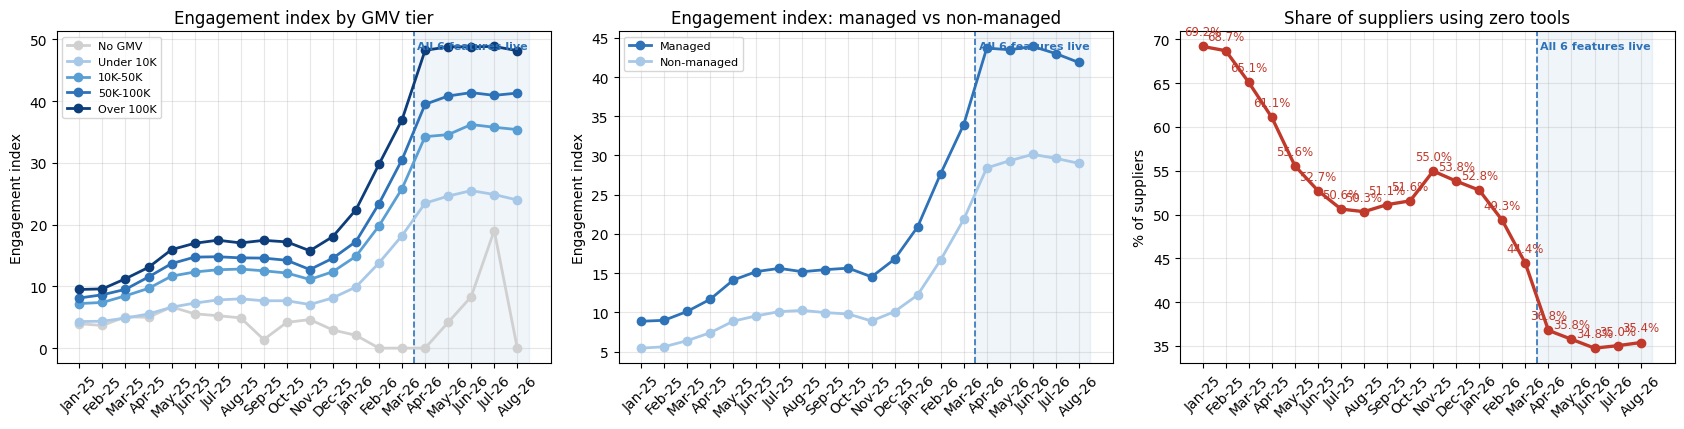

In [37]:
import matplotlib.pyplot as plt

d = df_n.copy()
for c in ('n_suppliers','engagement_index','pct_zero'):
    d[c] = d[c].astype(float)
months = fmt_months(sorted(d['mo'].unique()))
order  = sorted(d['mo'].unique())

def wavg(g):
    return (g['engagement_index']*g['n_suppliers']).sum()/g['n_suppliers'].sum()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

# 1. index by GMV tier
for tier, col in zip(sorted(d['gmv_tier'].unique()),
                     ['#d0d0d0','#a8c8e8','#5a9fd4','#2e72b8','#0d3d7a']):
    sub = d[d['gmv_tier']==tier].groupby('mo').apply(wavg).reindex(order)
    axes[0].plot(months, sub.values, marker='o', linewidth=2, color=col, label=tier[2:])
axes[0].set_title('Engagement index by GMV tier')
axes[0].set_ylabel('Engagement index'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_axisbelow(True)

# 2. managed vs non-managed
for flag, lbl, col in [(1,'Managed','#2e72b8'), (0,'Non-managed','#a8c8e8')]:
    sub = d[d['is_managed'].astype(int)==flag].groupby('mo').apply(wavg).reindex(order)
    axes[1].plot(months, sub.values, marker='o', linewidth=2, color=col, label=lbl)
axes[1].set_title('Engagement index: managed vs non-managed')
axes[1].set_ylabel('Engagement index'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_axisbelow(True)

# 3. zero-user share overall
tot = d.groupby('mo').apply(
    lambda g: (g['pct_zero']*g['n_suppliers']).sum()/g['n_suppliers'].sum()).reindex(order)
axes[2].plot(months, tot.values, marker='o', linewidth=2.4, color='#c0392b')
for x, y in zip(months, tot.values):
    axes[2].annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0,8),
                     ha='center', fontsize=8.5, color='#c0392b')
axes[2].set_title('Share of suppliers using zero tools')
axes[2].set_ylabel('% of suppliers'); axes[2].grid(alpha=0.3); axes[2].set_axisbelow(True)

for ax in axes:
    mark_full_instr(ax, order)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


---
### Output O — Stress tests as trends (Jan 2025 to Aug 2026)

Stress tests 5.1 (distribution) and 5.6 (month-on-month stability) shown over time rather than for a single month. The snapshot versions above are unchanged.


In [38]:
sql_dist_trend = """
WITH months AS (
  SELECT DATE_FORMAT(mo,'yyyy-MM') AS mo, mo AS mo_start, LAST_DAY(mo) AS mo_end
  FROM (SELECT EXPLODE(SEQUENCE(DATE '2025-01-01', DATE '2026-08-01', INTERVAL 1 MONTH)) AS mo)
),
sup AS (
  SELECT m.mo, m.mo_start, m.mo_end, l.supplier_id,
         MAX(CASE WHEN l.is_managed THEN 1 ELSE 0 END) AS is_managed,
         MAX(COALESCE(l.gmv_eur_l365,0))               AS gmv_l365
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, m.mo_start, m.mo_end, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
ev AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2025-01-01' AND '2026-08-31'
),
scored AS (
  SELECT s.mo, s.supplier_id, s.is_managed, s.gmv_l365, CAST(
      MAX(CASE WHEN e.container_name='ProductDetails' AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove','PickupSaveArea','MeetingPointAddAddressButton','PickupAddAreaButton','PickupAddAddressButton','PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierPerformance' AND e.event_identifier IN ('FilterProducts','SupplierBusinessPerformanceDateRangeChange','SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen','SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick','SupplierPerformanceByProductPageChange')) OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN ('SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange','SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierAgenda' AND e.event_identifier IN ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff','BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff')) OR (e.container_name='SupplierCalendar' AND e.event_identifier IN ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot','CalendarUnblockTimeSlot','CalendarUnblockOption')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule')) OR (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierSpecialOffers' AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierReviews' AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END)
  AS INT) AS n_feat
  FROM sup s LEFT JOIN ev e
    ON e.supplier_id = s.supplier_id AND e.event_date BETWEEN s.mo_start AND s.mo_end
  GROUP BY s.mo, s.supplier_id, s.is_managed, s.gmv_l365
)
SELECT mo, n_feat, COUNT(*) AS n_suppliers
FROM scored GROUP BY mo, n_feat ORDER BY mo, n_feat
"""
df_dist_t = spark.sql(sql_dist_trend)

sql_stab_trend = """
WITH months AS (
  SELECT DATE_FORMAT(mo,'yyyy-MM') AS mo, mo AS mo_start, LAST_DAY(mo) AS mo_end
  FROM (SELECT EXPLODE(SEQUENCE(DATE '2025-01-01', DATE '2026-08-01', INTERVAL 1 MONTH)) AS mo)
),
sup AS (
  SELECT m.mo, m.mo_start, m.mo_end, l.supplier_id,
         MAX(CASE WHEN l.is_managed THEN 1 ELSE 0 END) AS is_managed,
         MAX(COALESCE(l.gmv_eur_l365,0))               AS gmv_l365
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, m.mo_start, m.mo_end, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
ev AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2025-01-01' AND '2026-08-31'
),
scored AS (
  SELECT s.mo, s.supplier_id, s.is_managed, s.gmv_l365, CAST(
      MAX(CASE WHEN e.container_name='ProductDetails' AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove','PickupSaveArea','MeetingPointAddAddressButton','PickupAddAreaButton','PickupAddAddressButton','PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierPerformance' AND e.event_identifier IN ('FilterProducts','SupplierBusinessPerformanceDateRangeChange','SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen','SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick','SupplierPerformanceByProductPageChange')) OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN ('SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange','SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN (e.container_name='SupplierAgenda' AND e.event_identifier IN ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff','BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff')) OR (e.container_name='SupplierCalendar' AND e.event_identifier IN ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot','CalendarUnblockTimeSlot','CalendarUnblockOption')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule')) OR (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton')) THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierSpecialOffers' AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers') THEN 1 ELSE 0 END)
    + MAX(CASE WHEN e.container_name='SupplierReviews' AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END)
  AS INT) AS n_feat
  FROM sup s LEFT JOIN ev e
    ON e.supplier_id = s.supplier_id AND e.event_date BETWEEN s.mo_start AND s.mo_end
  GROUP BY s.mo, s.supplier_id, s.is_managed, s.gmv_l365
),
paired AS (
  SELECT a.mo AS mo_curr, a.supplier_id, a.n_feat AS feat_curr, b.n_feat AS feat_prev
  FROM scored a
  JOIN scored b ON b.supplier_id = a.supplier_id
   AND b.mo = DATE_FORMAT(ADD_MONTHS(TO_DATE(CONCAT(a.mo,'-01')), -1), 'yyyy-MM')
)
SELECT mo_curr AS mo, COUNT(*) AS n_paired,
  ROUND(100.0*SUM(CASE WHEN ABS(feat_curr-feat_prev) <= 1 THEN 1 ELSE 0 END)/COUNT(*),1) AS pct_within_1,
  ROUND(100.0*SUM(CASE WHEN feat_curr = feat_prev THEN 1 ELSE 0 END)/COUNT(*),1)          AS pct_no_change
FROM paired GROUP BY mo_curr ORDER BY mo_curr
"""
df_stab_t = spark.sql(sql_stab_trend)
display(df_stab_t)


,mo,n_paired,pct_within_1,pct_no_change
0,2025-02,32560,98.4,77.7
1,2025-03,32967,98.3,76.7
2,2025-04,33540,97.6,74.2
3,2025-05,34016,96.6,70.2
4,2025-06,35123,96.5,68.2
5,2025-07,35114,96.4,66.8
6,2025-08,35775,96.8,67.2
7,2025-09,36881,96.6,67.5
8,2025-10,37452,96.4,66.6
9,2025-11,37421,96.4,65.8


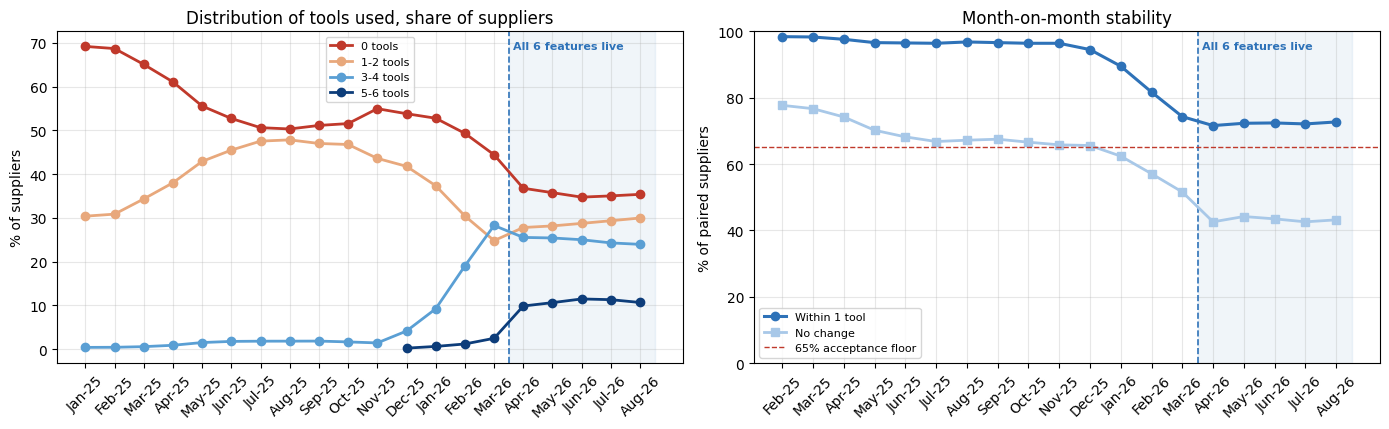

In [39]:
import matplotlib.pyplot as plt

dd = df_dist_t.copy(); dd['n_feat']=dd['n_feat'].astype(int); dd['n_suppliers']=dd['n_suppliers'].astype(float)
order = sorted(dd['mo'].unique()); months = fmt_months(order)
tot = dd.groupby('mo')['n_suppliers'].sum()

buckets = [('0 tools',[0],'#c0392b'), ('1-2 tools',[1,2],'#e8a87c'),
           ('3-4 tools',[3,4],'#5a9fd4'), ('5-6 tools',[5,6],'#0d3d7a')]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

for lbl, feats, col in buckets:
    share = (dd[dd['n_feat'].isin(feats)].groupby('mo')['n_suppliers'].sum()/tot*100).reindex(order)
    axes[0].plot(months, share.values, marker='o', linewidth=2, color=col, label=lbl)
axes[0].set_title('Distribution of tools used, share of suppliers')
axes[0].set_ylabel('% of suppliers'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_axisbelow(True)

ds = df_stab_t.copy()
ds['pct_within_1']=ds['pct_within_1'].astype(float); ds['pct_no_change']=ds['pct_no_change'].astype(float)
ds = ds.sort_values('mo')
m2 = fmt_months(ds['mo'].tolist())
axes[1].plot(m2, ds['pct_within_1'], marker='o', linewidth=2.2, color='#2e72b8', label='Within 1 tool')
axes[1].plot(m2, ds['pct_no_change'], marker='s', linewidth=2, color='#a8c8e8', label='No change')
axes[1].axhline(65, color='#c0392b', linestyle='--', linewidth=1, label='65% acceptance floor')
axes[1].set_title('Month-on-month stability')
axes[1].set_ylabel('% of paired suppliers'); axes[1].set_ylim(0,100)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_axisbelow(True)

mark_full_instr(axes[0], order)
mark_full_instr(axes[1], ds['mo'].tolist())
for ax in axes: ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


---
### Output L — Acquisition cohort (Jan 2025 – Jul 2026)

Groups suppliers by the quarter they first became active (bookable + booked any day in month).
Tracks average engagement at each subsequent month relative to activation (months 0–12).
Shows whether newer cohorts onboard into portal usage faster than older ones.

In [40]:
sql_cohort = '''
WITH months AS (
  SELECT
    DATE_FORMAT(mo, 'yyyy-MM') AS mo,
    mo AS mo_start,
    LAST_DAY(mo) AS mo_end
  FROM (SELECT EXPLODE(SEQUENCE(DATE '2025-01-01', DATE '2026-08-01', INTERVAL 1 MONTH)) AS mo)
),
supplier_months AS (
  SELECT m.mo, m.mo_start, m.mo_end, l.supplier_id
  FROM months m
  JOIN production.core_supply.agg_supplier_lifecycle_daily l
    ON l.snapshot_date BETWEEN m.mo_start AND m.mo_end
  GROUP BY m.mo, m.mo_start, m.mo_end, l.supplier_id
  HAVING MAX(CASE WHEN l.is_relevant THEN 1 ELSE 0 END) = 1
),
first_active AS (
  SELECT supplier_id, MIN(mo) AS cohort_mo
  FROM supplier_months GROUP BY supplier_id
),
events AS (
  SELECT supplier_id, container_name, event_identifier, event_date
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2025-01-01' AND '2026-08-31'
),

scored AS (
  SELECT
    sm.mo,
    sm.supplier_id,
    -- cohort quarter
    CONCAT('Q', QUARTER(DATE(fa.cohort_mo || '-01')), ' ', YEAR(DATE(fa.cohort_mo || '-01'))) AS cohort_qtr,
    CAST(MONTHS_BETWEEN(DATE(sm.mo || '-01'), DATE(fa.cohort_mo || '-01')) AS INT) AS months_since_activation,
    CAST(
      MAX(CASE WHEN e.container_name = 'ProductDetails'
               AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove','PickupSaveArea','MeetingPointAddAddressButton','PickupAddAreaButton','PickupAddAddressButton','PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END) +
      MAX(CASE WHEN (e.container_name = 'ProductDetails'
        AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
        OR (e.container_name = 'availability-and-pricing'
            AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing'))
      THEN 1 ELSE 0 END) +
      MAX(CASE WHEN
        (e.container_name='SupplierPerformance' AND e.event_identifier IN (
          'FilterProducts','SupplierBusinessPerformanceDateRangeChange',
          'SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen',
          'SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick',
          'SupplierPerformanceByProductPageChange'))
        OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN (
          'SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange',
          'SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange'))
      THEN 1 ELSE 0 END) +
      MAX(CASE WHEN
        (e.container_name='SupplierAgenda' AND e.event_identifier IN
         ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff',
          'BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff'))
        OR (e.container_name='SupplierCalendar' AND e.event_identifier IN
         ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot',
          'CalendarUnblockTimeSlot','CalendarUnblockOption'))
        OR (e.container_name = 'availability-and-pricing' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule'))
        OR (e.container_name = 'ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton'))
      THEN 1 ELSE 0 END) +
      MAX(CASE WHEN e.container_name='SupplierSpecialOffers'
        AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers')
      THEN 1 ELSE 0 END) +
      MAX(CASE WHEN e.container_name='SupplierReviews'
        AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END)
    AS DOUBLE) / 6.0 AS engagement_share
  FROM supplier_months sm
  JOIN first_active fa ON fa.supplier_id = sm.supplier_id
  LEFT JOIN events e ON sm.supplier_id = e.supplier_id
    AND e.event_date BETWEEN sm.mo_start AND sm.mo_end
  GROUP BY sm.mo, sm.supplier_id, fa.cohort_mo
)
SELECT
  cohort_qtr,
  months_since_activation,
  COUNT(*) AS n_suppliers,
  ROUND(AVG(engagement_share) * 100, 1) AS avg_engagement_pct
FROM scored
WHERE months_since_activation BETWEEN 0 AND 12
GROUP BY cohort_qtr, months_since_activation
ORDER BY cohort_qtr, months_since_activation
'''
df_l = spark.sql(sql_cohort)
display(df_l)

,cohort_qtr,months_since_activation,n_suppliers,avg_engagement_pct
0,Q1 2025,0,35877,5.9
1,Q1 2025,1,34775,6.1
2,Q1 2025,2,34229,7.0
3,Q1 2025,3,33538,8.1
4,Q1 2025,4,33051,10.2
...,...,...,...,...
60,Q4 2025,6,3832,28.6
61,Q4 2025,7,3768,28.1
62,Q4 2025,8,3723,27.8
63,Q4 2025,9,2211,26.8


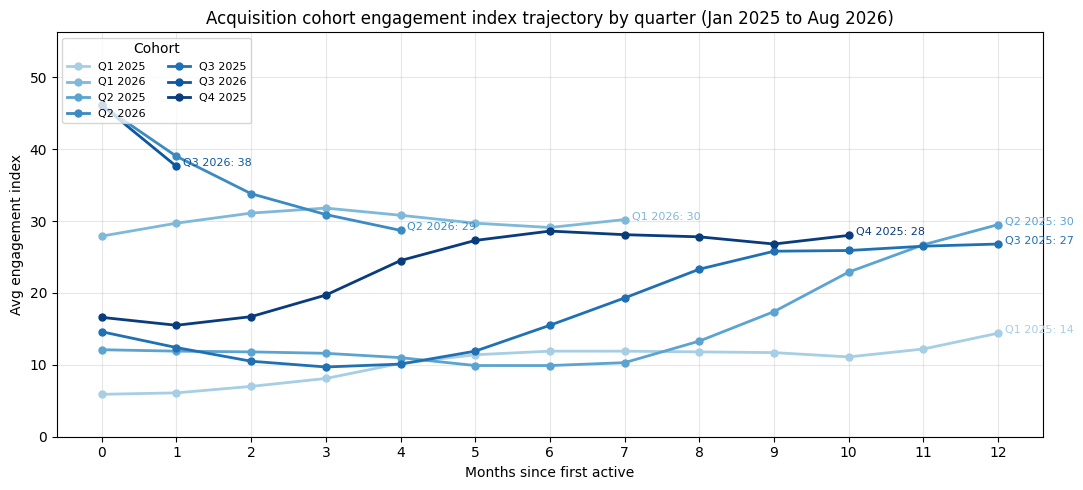

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df_l_pd = df_l.toPandas() if hasattr(df_l, 'toPandas') else df_l.copy()
df_l_pd['avg_engagement_pct']     = df_l_pd['avg_engagement_pct'].astype(float)
df_l_pd['months_since_activation'] = df_l_pd['months_since_activation'].astype(int)

cohorts = sorted(df_l_pd['cohort_qtr'].unique())
palette = plt.cm.Blues(np.linspace(0.35, 0.95, max(len(cohorts), 1)))

fig, ax = plt.subplots(figsize=(11, 5))

for cohort, color in zip(cohorts, palette):
    sub = df_l_pd[df_l_pd['cohort_qtr'] == cohort].sort_values('months_since_activation')
    if len(sub) < 2:
        continue
    ax.plot(sub['months_since_activation'], sub['avg_engagement_pct'],
            marker='o', linewidth=2, markersize=5, color=color, label=cohort)
    last = sub.iloc[-1]
    ax.annotate(f"{cohort}: {last['avg_engagement_pct']:.0f}",
                (last['months_since_activation'], last['avg_engagement_pct']),
                textcoords='offset points', xytext=(5, 0), fontsize=8, color=color)

ax.set_xlabel('Months since first active')
ax.set_ylabel('Avg engagement index')
ax.set_title('Acquisition cohort engagement index trajectory by quarter (Jan 2025 to Aug 2026)')
ax.set_xticks(range(0, 13))
ax.legend(title='Cohort', loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
if len(df_l_pd) > 0:
    ax.set_ylim(0, df_l_pd['avg_engagement_pct'].max() * 1.22)

plt.tight_layout()
plt.show()


---
### Output M — Engagement stability (July vs August 2026)

For suppliers active in both months, distribution of month-on-month score change.
A stable metric (most suppliers within ±1 feature) is a reliable indicator.
High volatility suggests the score reflects one-off events rather than consistent behaviour.

In [42]:
sql_stability = '''
WITH july_events AS (
  SELECT supplier_id, container_name, event_identifier
  FROM production.core_supply.agg_supplier_portal_events_session_daily
  WHERE event_date BETWEEN '2026-07-01' AND '2026-07-31'
),

july_suppliers AS (
  SELECT supplier_id
  FROM production.core_supply.agg_supplier_lifecycle_daily
  WHERE snapshot_date BETWEEN '2026-07-01' AND '2026-07-31'
  GROUP BY supplier_id
  HAVING MAX(CASE WHEN is_relevant THEN 1 ELSE 0 END) = 1
),
july_scored AS (
  SELECT s.supplier_id,
    CAST(
      MAX(CASE WHEN e.container_name='ProductDetails' AND e.event_identifier IN ('SaveStepButton','KeywordAdd','KeywordRemove','PickupSaveArea','MeetingPointAddAddressButton','PickupAddAreaButton','PickupAddAddressButton','PickupSaveAddress','TourOptionSavedWithGeometry','DropOffAddAddressButton','OptionManagementPanelSaveButton') THEN 1 ELSE 0 END) +
      MAX(CASE WHEN (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','CreatedAdditionalPricing','UpdatedAdditionalPricing')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('CreatedAdditionalPricing','UpdatedAdditionalPricing')) THEN 1 ELSE 0 END) +
      MAX(CASE WHEN (e.container_name='SupplierPerformance' AND e.event_identifier IN ('FilterProducts','SupplierBusinessPerformanceDateRangeChange','SupplierPerformanceByProductActionClick','SupplierBusinessPerformanceTooltipOpen','SupplierPerformanceTopActionClick','SupplierPerformanceByProductActionsTagClick','SupplierPerformanceByProductPageChange')) OR (e.container_name='SupplierProductPerformance' AND e.event_identifier IN ('SupplierProductPerformancePageRequest','SupplierProductPerformanceDateRangeChange','SupplierProductPerformanceActionClick','SupplierProductPerformanceGraphChange')) THEN 1 ELSE 0 END) +
      MAX(CASE WHEN (e.container_name='SupplierAgenda' AND e.event_identifier IN ('BlockDateButton','UnblockDateButton','SupplierTimeSlotVacanciesUpdate','UpdateCutOff','BulkUpdateBlockDate','BulkUpdateUnblockDate','BulkUpdateBookablePersons','BulkUpdateCutOff')) OR (e.container_name='SupplierCalendar' AND e.event_identifier IN ('CalendarUpdateParticipants','CalendarBlockOption','CalendarBlockTimeSlot','CalendarUnblockTimeSlot','CalendarUnblockOption')) OR (e.container_name='availability-and-pricing' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','AvailabilityAndPricingAddSchedule')) OR (e.container_name='ProductDetails' AND e.event_identifier IN ('AvailabilityAndPricingSaveAndContinueButton','OptionManagementPanelSaveButton')) THEN 1 ELSE 0 END) +
      MAX(CASE WHEN e.container_name='SupplierSpecialOffers' AND e.event_identifier IN ('CreateDealOffersHub','DeleteSpecialOffers') THEN 1 ELSE 0 END) +
      MAX(CASE WHEN e.container_name='SupplierReviews' AND e.event_identifier='ReviewCardReplySubmit' THEN 1 ELSE 0 END)
    AS DOUBLE) / 6.0 AS eng_jul
  FROM july_suppliers s
  LEFT JOIN july_events e ON s.supplier_id = e.supplier_id
  GROUP BY s.supplier_id
),
paired AS (
  SELECT
    j.supplier_id,
    j.eng_jul,
    v.supplier_engagement_share AS eng_aug,
    v.supplier_engagement_share - j.eng_jul AS delta
  FROM july_scored j
  JOIN v_supplier_engagement v ON v.supplier_id = j.supplier_id
)
SELECT
  CASE
    WHEN delta < -0.167 THEN 'down 2+ features'
    WHEN delta < -0.001 THEN 'down 1 feature'
    WHEN delta < 0.001  THEN 'no change'
    WHEN delta < 0.168  THEN 'up 1 feature'
    ELSE 'up 2+ features'
  END AS change_band,
  COUNT(*) AS n_suppliers,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_suppliers
FROM paired
GROUP BY change_band
ORDER BY MIN(delta)
'''
df_m = spark.sql(sql_stability)
display(df_m)

,change_band,n_suppliers,pct_suppliers
0,down 2+ features,8314,15.1
1,down 1 feature,8619,15.7
2,no change,23722,43.2
3,up 1 feature,7586,13.8
4,up 2+ features,6687,12.2


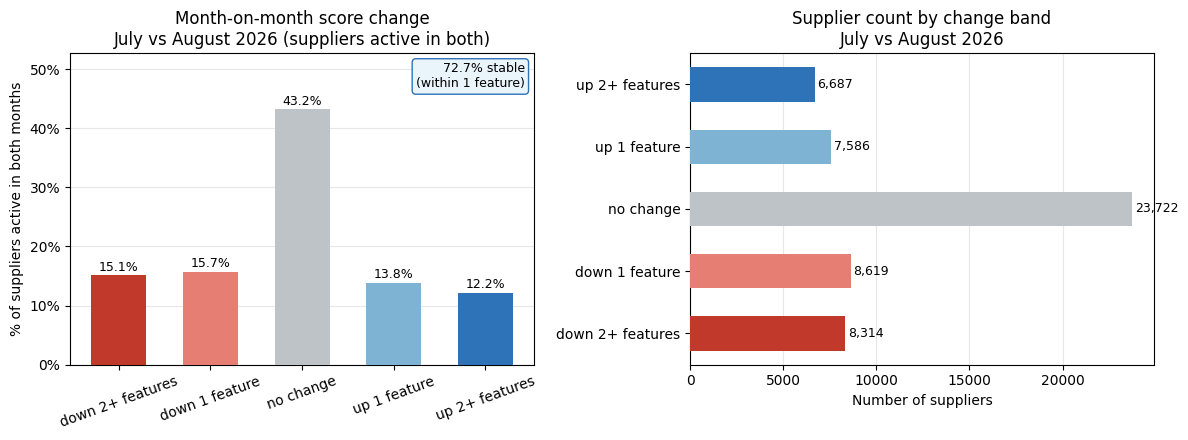

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

df_m_pd = df_m.toPandas() if hasattr(df_m, 'toPandas') else df_m.copy()
df_m_pd['pct_suppliers'] = df_m_pd['pct_suppliers'].astype(float)
df_m_pd['n_suppliers']   = df_m_pd['n_suppliers'].astype(int)

order = ['down 2+ features', 'down 1 feature', 'no change', 'up 1 feature', 'up 2+ features']
df_m_pd['change_band'] = pd.Categorical(df_m_pd['change_band'], categories=order, ordered=True)
df_m_pd = df_m_pd.sort_values('change_band')

bar_colors = ['#c0392b', '#e67e73', '#bdc3c7', '#7fb3d3', '#2e72b8']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(df_m_pd['change_band'], df_m_pd['pct_suppliers'],
                   color=bar_colors[:len(df_m_pd)], width=0.6, zorder=3)
for bar, val in zip(bars, df_m_pd['pct_suppliers']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('% of suppliers active in both months')
axes[0].set_title('Month-on-month score change\nJuly vs August 2026 (suppliers active in both)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, max(df_m_pd['pct_suppliers']) * 1.22)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

stable_pct = df_m_pd[df_m_pd['change_band'].isin(['no change', 'down 1 feature', 'up 1 feature'])]['pct_suppliers'].sum()
axes[0].text(0.98, 0.97, f'{stable_pct:.1f}% stable\n(within 1 feature)',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='#eaf4fb', ec='#2e72b8'))

bars2 = axes[1].barh(df_m_pd['change_band'], df_m_pd['n_suppliers'],
                     color=bar_colors[:len(df_m_pd)], height=0.55, zorder=3)
for bar, val in zip(bars2, df_m_pd['n_suppliers']):
    axes[1].text(val + 150, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of suppliers')
axes[1].set_title('Supplier count by change band\nJuly vs August 2026')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


---
### Diagnostic — Event first-seen dates & monthly volume

Checks when each primary signal event **first appeared** in the portal events table.  
A hard step-change on a single date = instrumentation launch (data artefact, not real behaviour change).  
A gradual rise = organic adoption, UX change, or campaign.


In [44]:
sql_first_seen = '''
SELECT
  container_name,
  event_identifier,
  MIN(event_date) AS first_seen_date,
  COUNT(DISTINCT DATE_TRUNC('month', event_date)) AS months_present
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-01-01' AND '2026-08-31'
  AND (container_name, event_identifier) IN (
    -- F1 Content Editing (direct saves)
    ('ProductDetails',             'SaveStepButton'),
    ('ProductDetails',             'KeywordAdd'),
    ('ProductDetails',             'KeywordRemove'),
    ('ProductDetails',             'PickupSaveArea'),
    ('ProductDetails',             'PickupSaveAddress'),
    ('ProductDetails',             'MeetingPointAddAddressButton'),
    ('ProductDetails',             'PickupAddAreaButton'),
    ('ProductDetails',             'PickupAddAddressButton'),
    ('ProductDetails',             'DropOffAddAddressButton'),
    ('ProductDetails',             'TourOptionSavedWithGeometry'),
    ('ProductDetails',             'OptionManagementPanelSaveButton'),
    -- F2 Pricing (pricing create/update events only)
    ('ProductDetails',             'CreatedAdditionalPricing'),
    ('ProductDetails',             'UpdatedAdditionalPricing'),
    -- F3 — interaction events (page load excluded)
    ('SupplierPerformance',        'FilterProducts'),
    ('SupplierPerformance',        'SupplierBusinessPerformanceDateRangeChange'),
    ('SupplierPerformance',        'SupplierPerformanceByProductActionClick'),
    ('SupplierPerformance',        'SupplierPerformanceTopActionClick'),
    ('SupplierProductPerformance', 'SupplierProductPerformancePageRequest'),
    ('SupplierProductPerformance', 'SupplierProductPerformanceGraphChange'),
    -- F4
    ('SupplierAgenda',             'BlockDateButton'),
    ('availability-and-pricing',   'AvailabilityAndPricingAddSchedule'),
    ('ProductDetails',             'AvailabilityAndPricingSaveAndContinueButton'),
    -- F5
    ('SupplierSpecialOffers',      'CreateDealOffersHub'),
    ('SupplierSpecialOffers',      'DeleteSpecialOffers'),
    -- F6 Reviews
    ('SupplierReviews',            'ReviewCardReplySubmit')
  )
GROUP BY container_name, event_identifier
ORDER BY first_seen_date, container_name
'''
display(spark.sql(sql_first_seen))


,container_name,event_identifier,first_seen_date,months_present
0,ProductDetails,PickupAddAddressButton,2026-01-01,8
1,ProductDetails,DropOffAddAddressButton,2026-01-01,8
2,ProductDetails,PickupSaveAddress,2026-01-01,8
3,ProductDetails,KeywordRemove,2026-01-01,8
4,ProductDetails,SaveStepButton,2026-01-01,8
5,ProductDetails,OptionManagementPanelSaveButton,2026-01-01,8
6,ProductDetails,KeywordAdd,2026-01-01,8
7,ProductDetails,PickupSaveArea,2026-01-01,8
8,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,2026-01-01,8
9,ProductDetails,PickupAddAreaButton,2026-01-01,8


In [45]:
# Monthly volume per key event
sql_monthly_vol = '''
SELECT
  DATE_TRUNC('month', event_date) AS month,
  container_name,
  event_identifier,
  COUNT(*)                        AS n_events,
  COUNT(DISTINCT supplier_id)     AS n_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-01-01' AND '2026-08-31'
  AND (container_name, event_identifier) IN (
    -- F1 Content Editing (direct saves)
    ('ProductDetails',             'SaveStepButton'),
    ('ProductDetails',             'KeywordAdd'),
    ('ProductDetails',             'KeywordRemove'),
    ('ProductDetails',             'PickupSaveArea'),
    ('ProductDetails',             'PickupSaveAddress'),
    ('ProductDetails',             'MeetingPointAddAddressButton'),
    ('ProductDetails',             'PickupAddAreaButton'),
    ('ProductDetails',             'PickupAddAddressButton'),
    ('ProductDetails',             'DropOffAddAddressButton'),
    ('ProductDetails',             'TourOptionSavedWithGeometry'),
    ('ProductDetails',             'OptionManagementPanelSaveButton'),
    -- F2 Pricing (pricing create/update events only)
    ('ProductDetails',             'CreatedAdditionalPricing'),
    ('ProductDetails',             'UpdatedAdditionalPricing'),
    -- F3 — interaction events (page load excluded)
    ('SupplierPerformance',        'FilterProducts'),
    ('SupplierPerformance',        'SupplierBusinessPerformanceDateRangeChange'),
    ('SupplierPerformance',        'SupplierPerformanceByProductActionClick'),
    ('SupplierPerformance',        'SupplierPerformanceTopActionClick'),
    ('SupplierProductPerformance', 'SupplierProductPerformancePageRequest'),
    ('SupplierProductPerformance', 'SupplierProductPerformanceGraphChange'),
    -- F4
    ('SupplierAgenda',             'BlockDateButton'),
    ('availability-and-pricing',   'AvailabilityAndPricingAddSchedule'),
    ('ProductDetails',             'AvailabilityAndPricingSaveAndContinueButton'),
    -- F5
    ('SupplierSpecialOffers',      'CreateDealOffersHub'),
    ('SupplierSpecialOffers',      'DeleteSpecialOffers'),
    -- F6 Reviews
    ('SupplierReviews',            'ReviewCardReplySubmit')
  )
GROUP BY 1, 2, 3
ORDER BY container_name, event_identifier, month
'''
df_vol = spark.sql(sql_monthly_vol)
display(df_vol)


,month,container_name,event_identifier,n_events,n_suppliers
0,2026-01-01 00:00:00+01:00,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,8452,3965
1,2026-02-01 00:00:00+01:00,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,25089,9302
2,2026-03-01 00:00:00+01:00,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,48328,15292
3,2026-04-01 00:00:00+02:00,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,50218,15428
4,2026-05-01 00:00:00+02:00,ProductDetails,AvailabilityAndPricingSaveAndContinueButton,51572,16263
...,...,...,...,...,...
180,2026-04-01 00:00:00+02:00,availability-and-pricing,AvailabilityAndPricingAddSchedule,19884,9751
181,2026-05-01 00:00:00+02:00,availability-and-pricing,AvailabilityAndPricingAddSchedule,21587,10479
182,2026-06-01 00:00:00+02:00,availability-and-pricing,AvailabilityAndPricingAddSchedule,21574,10307
183,2026-07-01 00:00:00+02:00,availability-and-pricing,AvailabilityAndPricingAddSchedule,22302,10135


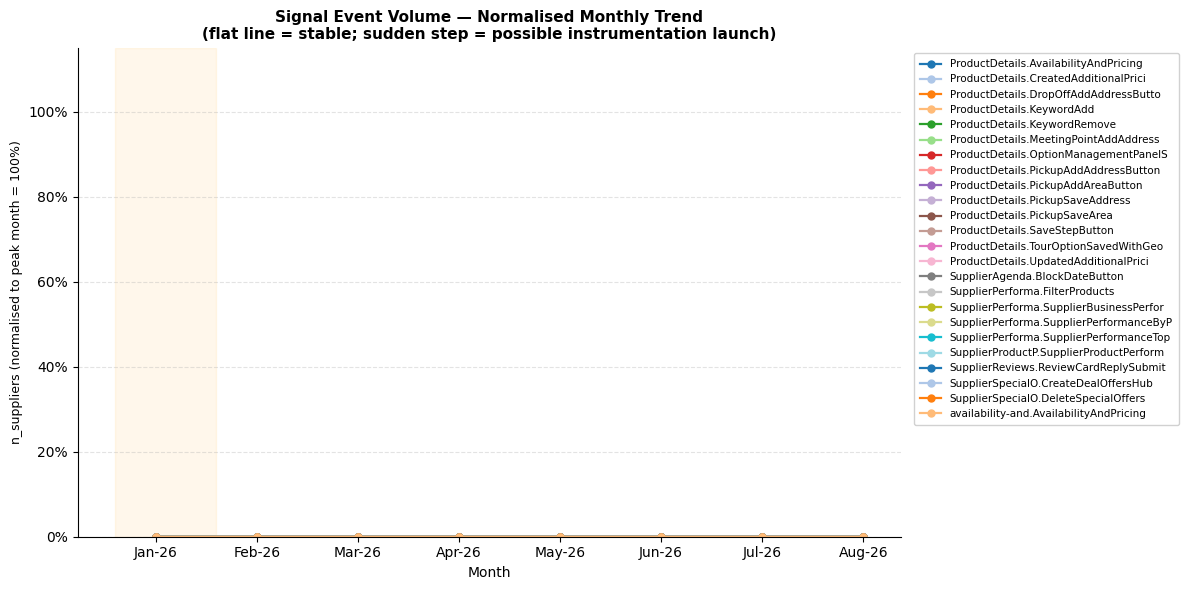


Interpretation guide:
  - Flat or smoothly rising → stable/organic growth
  - Hard jump from 0 at a specific month → event first instrumented that month
  - Spike then drop → campaign or one-time GYG communication


In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Pivot: one row per (container, event), columns = months
df_vol['month_label'] = pd.to_datetime(df_vol['month']).dt.strftime('%Y-%m')
df_vol['signal'] = df_vol['container_name'].str[:16] + '.' + df_vol['event_identifier'].str[:22]

pivot = df_vol.pivot_table(
    index='signal', columns='month_label',
    values='n_suppliers', aggfunc='sum', fill_value=0
)

# Normalise each row to its own max so all lines fit on 0-100%
pivot_norm = pivot.div(pivot.max(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
months = fmt_months(sorted(df_vol['month_label'].unique()))

colors = plt.cm.tab20.colors
for i, (signal, row) in enumerate(pivot_norm.iterrows()):
    vals = [row.get(m, 0) for m in months]
    ax.plot(months, vals, marker='o', linewidth=1.6, markersize=5,
            color=colors[i % len(colors)], label=signal)

ax.axvspan(-0.4, 0.6, alpha=0.08, color='orange', zorder=0)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('n_suppliers (normalised to peak month = 100%)', fontsize=9)
ax.set_title('Signal Event Volume — Normalised Monthly Trend\n'
             '(flat line = stable; sudden step = possible instrumentation launch)',
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 115)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=7.5,
          framealpha=0.9, borderpad=0.6)

plt.tight_layout()
plt.show()
print()
print('Interpretation guide:')
print('  - Flat or smoothly rising → stable/organic growth')
print('  - Hard jump from 0 at a specific month → event first instrumented that month')
print('  - Spike then drop → campaign or one-time GYG communication')


---
### Jump Diagnosis — Step 1: Is the denominator (eligible supplier base) shifting?

Reach rates can change simply because more or fewer suppliers are eligible each month.  
Check whether `n_eligible` grows, shrinks, or stays flat before concluding anything about behaviour.


In [47]:
sql_denom = '''
SELECT
  snapshot_date,
  lifecycle_stage,
  COUNT(*)                                                        AS n_total,
  SUM(CASE WHEN (tours_pre_activated_count + tours_activated_count) > 0
           THEN 1 ELSE 0 END)                                    AS n_eligible_bookable,
  SUM(CASE WHEN bookings_l365 > 0 THEN 1 ELSE 0 END)            AS n_eligible_bookings,
  SUM(CASE WHEN is_relevant THEN 1 ELSE 0 END)                  AS n_is_relevant
FROM production.core_supply.agg_supplier_lifecycle_daily
WHERE snapshot_date IN ('2026-01-31','2026-02-28','2026-03-31',
                        '2026-04-30','2026-05-31','2026-06-30','2026-07-31','2026-08-31')
  AND lifecycle_stage = '03. Activated'
GROUP BY snapshot_date, lifecycle_stage
ORDER BY snapshot_date, lifecycle_stage
'''
display(spark.sql(sql_denom))


,snapshot_date,lifecycle_stage,n_total,n_eligible_bookable,n_eligible_bookings,n_is_relevant
0,2026-01-31,03. Activated,30905,30905,30750,29535
1,2026-02-28,03. Activated,31815,31815,31650,30643
2,2026-03-31,03. Activated,33118,33118,32949,31956
3,2026-04-30,03. Activated,34619,34619,34436,33447
4,2026-05-31,03. Activated,36504,36504,36319,35212
5,2026-06-30,03. Activated,38362,38362,38181,37015
6,2026-07-31,03. Activated,40522,40522,40363,39166
7,2026-08-31,03. Activated,42602,42602,42428,41149


---
### Jump Diagnosis — Step 2: Exact date each signal event first fired

If `first_seen_date` is **after 2026-01-01**, the pre-launch months score 0% for that event — not because suppliers weren't active, but because the event wasn't instrumented yet.  
This is the most common cause of sudden jumps in portal engagement metrics.


In [48]:
sql_debut = '''
SELECT
  container_name,
  event_identifier,
  MIN(event_date)                     AS first_seen_date,
  MAX(event_date)                     AS last_seen_date,
  COUNT(DISTINCT event_date)          AS n_days_present,
  COUNT(DISTINCT supplier_id)         AS total_unique_suppliers
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2025-10-01' AND '2026-08-31'
  AND (container_name, event_identifier) IN (
    -- F1 direct saves
    ('ProductDetails',             'SaveStepButton'),
    ('SupplierCreateProduct',      'SaveStepButton'),
    ('ProductDetails',             'KeywordAdd'),
    ('ProductDetails',             'KeywordRemove'),
    ('ProductDetails',             'PickupSaveArea'),
    ('ProductDetails',             'PickupSaveAddress'),
    ('ProductDetails',             'MeetingPointAddAddressButton'),
    ('ProductDetails',             'PickupAddAreaButton'),
    ('ProductDetails',             'PickupAddAddressButton'),
    ('ProductDetails',             'DropOffAddAddressButton'),
    ('ProductDetails',             'TourOptionSavedWithGeometry'),
    ('ProductDetails',             'OptionManagementPanelSaveButton'),
    -- F2
    ('ProductDetails',             'CreatedAdditionalPricing'),
    ('ProductDetails',             'UpdatedAdditionalPricing'),
    ('SupplierPerformance',        'SupplierPerformancePageRequest'),
    ('SupplierProductPerformance', 'SupplierProductPerformancePageRequest'),
    ('SupplierAgenda',             'BlockDateButton'),
    ('SupplierAgenda',             'UnblockDateButton'),
    ('SupplierCalendar',           'CalendarBlockOption'),
    ('availability-and-pricing',   'AvailabilityAndPricingAddSchedule'),
    ('availability-and-pricing',   'AvailabilityAndPricingSaveAndContinueButton'),
    ('ProductDetails',             'AvailabilityAndPricingSaveAndContinueButton'),
    
    ('SupplierSpecialOffers',      'CreateDealOffersHub'),
    ('SupplierSpecialOffers',      'DeleteSpecialOffers'),
    ('SupplierReviews',            'ReviewCardReplySubmit')
  )
GROUP BY container_name, event_identifier
ORDER BY first_seen_date
'''
df_debut = spark.sql(sql_debut)
display(df_debut)

# Flag events that first appeared AFTER the trend window start
import pandas as pd
late_starts = df_debut[pd.to_datetime(df_debut['first_seen_date']) > pd.Timestamp('2026-01-01')]
if len(late_starts):
    print(f'\n⚠️  {len(late_starts)} events first fired AFTER 2026-01-01 — these cause artificial jumps:')
    print(late_starts[['container_name','event_identifier','first_seen_date']].to_string(index=False))
else:
    print('\n✅ All signal events present from 2026-01-01 — no instrumentation gaps within the trend window.')


,container_name,event_identifier,first_seen_date,last_seen_date,n_days_present,total_unique_suppliers
0,availability-and-pricing,AvailabilityAndPricingAddSchedule,2025-10-01,2026-08-31,335,61733
1,SupplierCalendar,CalendarBlockOption,2025-10-01,2026-08-31,335,11289
2,SupplierCreateProduct,SaveStepButton,2025-10-01,2026-08-31,335,85966
3,SupplierAgenda,BlockDateButton,2025-10-01,2026-08-31,335,35596
4,SupplierSpecialOffers,CreateDealOffersHub,2025-10-01,2026-08-31,335,15116
5,availability-and-pricing,AvailabilityAndPricingSaveAndContinueButton,2025-10-01,2026-08-31,335,11395
6,SupplierReviews,ReviewCardReplySubmit,2025-10-01,2026-08-31,335,26195
7,SupplierSpecialOffers,DeleteSpecialOffers,2025-10-01,2026-08-31,335,9739
8,SupplierAgenda,UnblockDateButton,2025-10-01,2026-08-31,335,28779
9,ProductDetails,PickupAddAddressButton,2025-12-19,2026-08-31,240,3894



⚠️  5 events first fired AFTER 2026-01-01 — these cause artificial jumps:
            container_name                      event_identifier first_seen_date
            ProductDetails              CreatedAdditionalPricing      2026-02-02
            ProductDetails              UpdatedAdditionalPricing      2026-02-02
       SupplierPerformance        SupplierPerformancePageRequest      2026-02-17
SupplierProductPerformance SupplierProductPerformancePageRequest      2026-02-17
            ProductDetails           TourOptionSavedWithGeometry      2026-04-13


---
### Jump Diagnosis — Step 3: Daily supplier count per event (pinpoint the jump date)

A hard step-change that starts **on a single specific date** = instrumentation launch or product go-live.  
A gradual ramp = organic adoption. A spike then drop = GYG campaign or seasonal.


In [49]:
sql_daily = '''
SELECT
  event_date,
  container_name,
  event_identifier,
  COUNT(DISTINCT supplier_id) AS n_suppliers_daily
FROM production.core_supply.agg_supplier_portal_events_session_daily
WHERE event_date BETWEEN '2026-01-01' AND '2026-08-31'
  AND (container_name, event_identifier) IN (
    -- F1 direct saves
    ('ProductDetails',             'SaveStepButton'),
    ('SupplierCreateProduct',      'SaveStepButton'),
    ('ProductDetails',             'KeywordAdd'),
    ('ProductDetails',             'KeywordRemove'),
    ('ProductDetails',             'PickupSaveArea'),
    ('ProductDetails',             'PickupSaveAddress'),
    ('ProductDetails',             'MeetingPointAddAddressButton'),
    ('ProductDetails',             'PickupAddAreaButton'),
    ('ProductDetails',             'PickupAddAddressButton'),
    ('ProductDetails',             'DropOffAddAddressButton'),
    ('ProductDetails',             'TourOptionSavedWithGeometry'),
    ('ProductDetails',             'OptionManagementPanelSaveButton'),
    -- F2 pricing
    ('ProductDetails',             'AvailabilityAndPricingSaveAndContinueButton'),
    ('ProductDetails',             'CreatedAdditionalPricing'),
    ('ProductDetails',             'UpdatedAdditionalPricing'),
    ('availability-and-pricing',   'CreatedAdditionalPricing'),
    ('availability-and-pricing',   'UpdatedAdditionalPricing'),
    -- F3 performance — interaction events
    ('SupplierPerformance',        'FilterProducts'),
    ('SupplierPerformance',        'SupplierBusinessPerformanceDateRangeChange'),
    ('SupplierPerformance',        'SupplierPerformanceByProductActionClick'),
    ('SupplierProductPerformance', 'SupplierProductPerformancePageRequest'),
    -- F4 availability
    ('SupplierAgenda',             'BlockDateButton'),
    ('availability-and-pricing',   'AvailabilityAndPricingAddSchedule'),
    -- F5 special offers
    ('SupplierSpecialOffers',      'CreateDealOffersHub'),
    ('SupplierSpecialOffers',      'DeleteSpecialOffers'),
    -- F6 reviews
    ('SupplierReviews',            'ReviewCardReplySubmit')
  )
GROUP BY event_date, container_name, event_identifier
ORDER BY container_name, event_identifier, event_date
'''
df_daily = spark.sql(sql_daily)


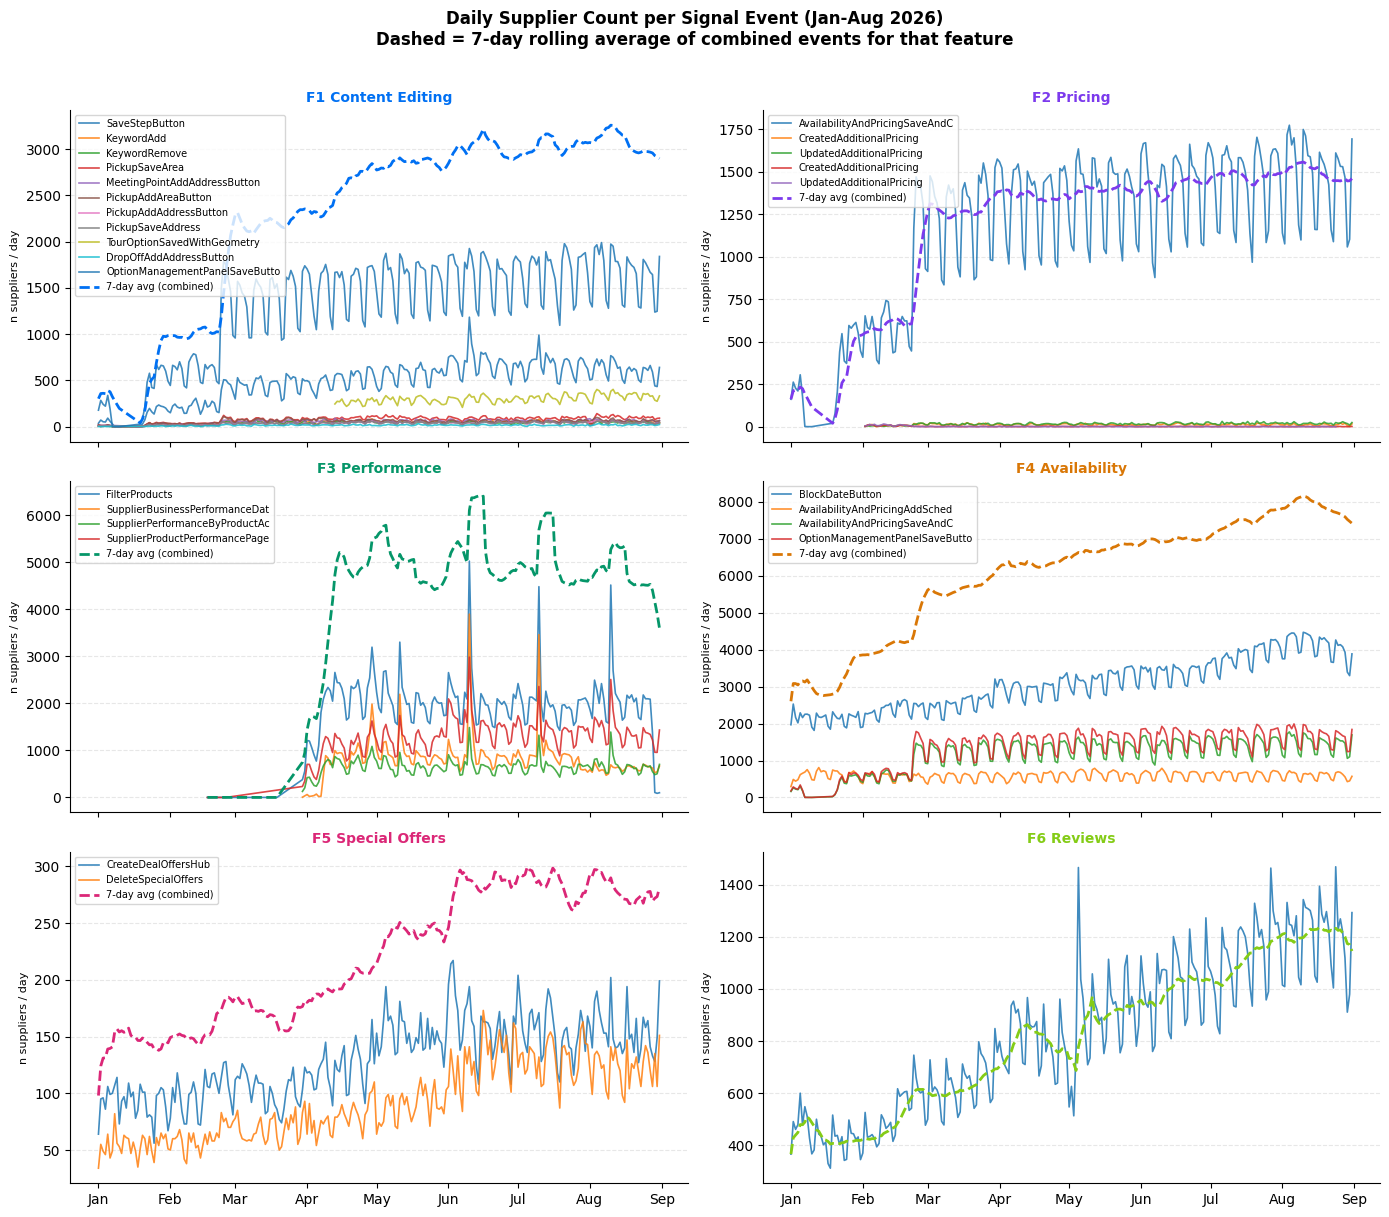

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 6 features in the metric
feature_events = {
    'F1 Content Editing':    [('ProductDetails','SaveStepButton'),
                              ('ProductDetails','KeywordAdd'),
                              ('ProductDetails','KeywordRemove'),
                              ('ProductDetails','PickupSaveArea'),
                              ('ProductDetails','MeetingPointAddAddressButton'),
                              ('ProductDetails','PickupAddAreaButton'),
                              ('ProductDetails','PickupAddAddressButton'),
                              ('ProductDetails','PickupSaveAddress'),
                              ('ProductDetails','TourOptionSavedWithGeometry'),
                              ('ProductDetails','DropOffAddAddressButton'),
                              ('ProductDetails','OptionManagementPanelSaveButton')],
    'F2 Pricing':            [('ProductDetails','AvailabilityAndPricingSaveAndContinueButton'),
                              ('ProductDetails','CreatedAdditionalPricing'),
                              ('ProductDetails','UpdatedAdditionalPricing'),
                              ('availability-and-pricing','CreatedAdditionalPricing'),
                              ('availability-and-pricing','UpdatedAdditionalPricing')],
    'F3 Performance':        [('SupplierPerformance','FilterProducts'),
                              ('SupplierPerformance','SupplierBusinessPerformanceDateRangeChange'),
                              ('SupplierPerformance','SupplierPerformanceByProductActionClick'),
                              ('SupplierPerformance','SupplierPerformanceTopActionClick'),
                              ('SupplierProductPerformance','SupplierProductPerformancePageRequest'),
                              ('SupplierProductPerformance','SupplierProductPerformanceGraphChange')],
    'F4 Availability':       [('SupplierAgenda','BlockDateButton'),
                              ('availability-and-pricing','AvailabilityAndPricingAddSchedule'),
                              ('ProductDetails','AvailabilityAndPricingSaveAndContinueButton'),
                              ('ProductDetails','OptionManagementPanelSaveButton')],
    'F5 Special Offers':     [('SupplierSpecialOffers','CreateDealOffersHub'),
                              ('SupplierSpecialOffers','DeleteSpecialOffers')],
    'F6 Reviews':            [('SupplierReviews','ReviewCardReplySubmit')],
}

df_daily['event_date'] = pd.to_datetime(df_daily['event_date'])

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

colors = ['#0070f3','#7c3aed','#059669','#d97706','#db2777','#84cc16']

for ax, (fname, evts), color in zip(axes, feature_events.items(), colors):
    for container, event in evts:
        mask = ((df_daily['container_name'] == container) &
                (df_daily['event_identifier'] == event))
        sub = df_daily[mask].sort_values('event_date')
        if not sub.empty:
            label = event[:30]
            ax.plot(sub['event_date'], sub['n_suppliers_daily'],
                    linewidth=1.2, alpha=0.85, label=label)

    # 7-day rolling average
    frames = [
        df_daily[(df_daily['container_name']==c) & (df_daily['event_identifier']==e)]
        for c,e in evts if not df_daily[(df_daily['container_name']==c) &
                                        (df_daily['event_identifier']==e)].empty
    ]
    all_evts = pd.concat(frames) if frames else pd.DataFrame()
    if not all_evts.empty:
        total = all_evts.groupby('event_date')['n_suppliers_daily'].sum().reset_index()
        total = total.sort_values('event_date')
        roll  = total.set_index('event_date')['n_suppliers_daily'].rolling('7D').mean()
        ax.plot(roll.index, roll.values, color=color, linewidth=2,
                linestyle='--', label='7-day avg (combined)', zorder=5)

    ax.set_title(fname, fontsize=10, fontweight='bold', color=color)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_ylabel('n suppliers / day', fontsize=8)
    if len(evts) > 1:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Daily Supplier Count per Signal Event (Jan-Aug 2026)\n'
             'Dashed = 7-day rolling average of combined events for that feature',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
### Jump Diagnosis — Step 4: Read the results

Use the outputs above to fill in this verdict table:

| Feature | Jump visible? | Cause type | Evidence |
|---|---|---|---|
| F1 Content Editing | TBD | Instrumentation / Organic / Campaign | `first_seen_date` of `ProductDetails.SaveStepButton`, pickup/meeting point saves, and option panel proxy events |
| F2 Pricing | TBD | Instrumentation / Organic / Campaign | `first_seen_date` of `ProductDetails.CreatedAdditionalPricing` and `UpdatedAdditionalPricing` |
| F3 Performance Views | Yes, Jan to Mar | Known: container launched 2026-02-17 | Confirmed from dbt PR / portal release notes |
| F4 Availability | TBD | Instrumentation / Organic / Campaign | `first_seen_date` of `availability-and-pricing` events |
| F5 Special Offers | TBD | Seasonal / Campaign | Check if jump coincides with a supplier newsletter |
| F6 Review Responses | TBD | Campaign / Organic | Check if jump follows a GYG review nudge email |

**Decision rule:**
- `first_seen_date` > 2026-01-01 for a key signal: instrumentation artefact; exclude pre-launch months from the trend, set a v1 baseline from launch month onwards
- `first_seen_date` = 2026-01-01 but daily chart shows a hard step on a specific date: product/UX go-live; check portal release notes for that date
- Gradual rise across 2-3 months: organic adoption or feature discovery
- Spike in one month then drop: GYG campaign or seasonal; verify against CRM send dates


---
## Summary

### Feature map (v1) — 6 features

| # | Feature | Eligibility | Signal | Status |
|---|---|---|---|---|
| F1 | Content Editing | `bookable_activity_count > 0` | `SaveStepButton`, keyword/pickup/address saves, `OptionManagementPanelSaveButton` | included |
| F2 | Pricing | `bookable_activity_count > 0` | `AvailabilityAndPricingSaveAndContinueButton`, `CreatedAdditionalPricing`, `UpdatedAdditionalPricing` | included |
| F3 | Performance Views | `bookings_l365 > 0` | Interaction events only (filter, date range, drilldown) | included |
| F4 | Availability | `bookable_activity_count > 0` | Confirmed saves across 4 surfaces, `OptionManagementPanelSaveButton` | included |
| F5 | Special Offers | `bookable_activity_count > 0` | `CreateDealOffersHub`, `DeleteSpecialOffers` | included |
| F6 | Review Responses | `bookings_l365 > 0` | `ReviewCardReplySubmit` | included |

### v2 backlog
| Issue | Fix |
|---|---|
| F1 proxy understates content-edit rate | Join `supply.fact_content_review` or instrument `ContentPublishedAndLive` |
| F5 proxy: no `SpecialOfferSaved` event | Instrument `SpecialOfferSaved` |
| Onboarding window truncated for most cohort | Restrict to `acquisition_date + 30 <= latest snapshot` |

---